<a href="https://colab.research.google.com/github/ccwu0918/nqu_meta/blob/master/BlockChain_NFT_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFT 智能合約開發全攻略! 發行NFT 背後的技術實戰及原理! 盲盒、公開發售怎麼做到的?

https://github.com/ccwu0918/nqu_meta/blob/master/contracts/nqu_meta_nft.sol

https://youtu.be/3vWw9Xt48bs?si=p3-sw4TgWSTqvhPs

以下是影片中提到的連結

•	Metamask 安裝-
https://metamask.io/

•	Sepolia faucet 測試幣領取-
1. https://www.alchemy.com/faucets/ethereum-sepolia
2. https://faucet.chainstack.com/sepolia-testnet-faucet
3. https://sepoliafaucet.com/
4. https://www.ankr.com/rpc/eth/eth_sepolia/
5. https://faucet.quicknode.com/ethereum/sepolia
6. https://getblock.io/faucet/eth-sepolia/
7. https://github.com/eth-clients/sepolia

•	Monad Testnet 測試幣領取-
1. https://www.alchemy.com/faucets/monad-testnet

•	MegaETH Testnet 測試幣領取-
https://thirdweb.com/megaeth-testnet

•	ETH 線上編輯器-
https://remix.ethereum.org

•	Nic Meta 智能合約範例-
https://github.com/niclin/nic_meta/blob/master/contracts/nic_meta_nft.sol

•	ETH 轉Gwei -
https://eth-converter.com

•	OpenSea 測試網路-
https://testnets.opensea.io

•	HashLips 組圖專案-
https://github.com/HashLips/hashlips_art_engine

•	IPFS 上傳空間-
https://www.pinata.cloud/

章節
00:00 實戰前說明
01:53 合約開發教學
09:20 上傳拼圖步驟

合約參考來源
•	BAYC (https://etherscan.io/address/0xbc4ca0eda7647a8ab7c2061c2e118a18a936f13d#code)
•	YOLO cat (https://etherscan.io/address/0x7169887b559f625a81144eee8ac784d1d8b4920f#code)
•	onion meta (https://etherscan.io/address/0xae71193d1e914eea9a3164b5f52a19c86949ff50#code)

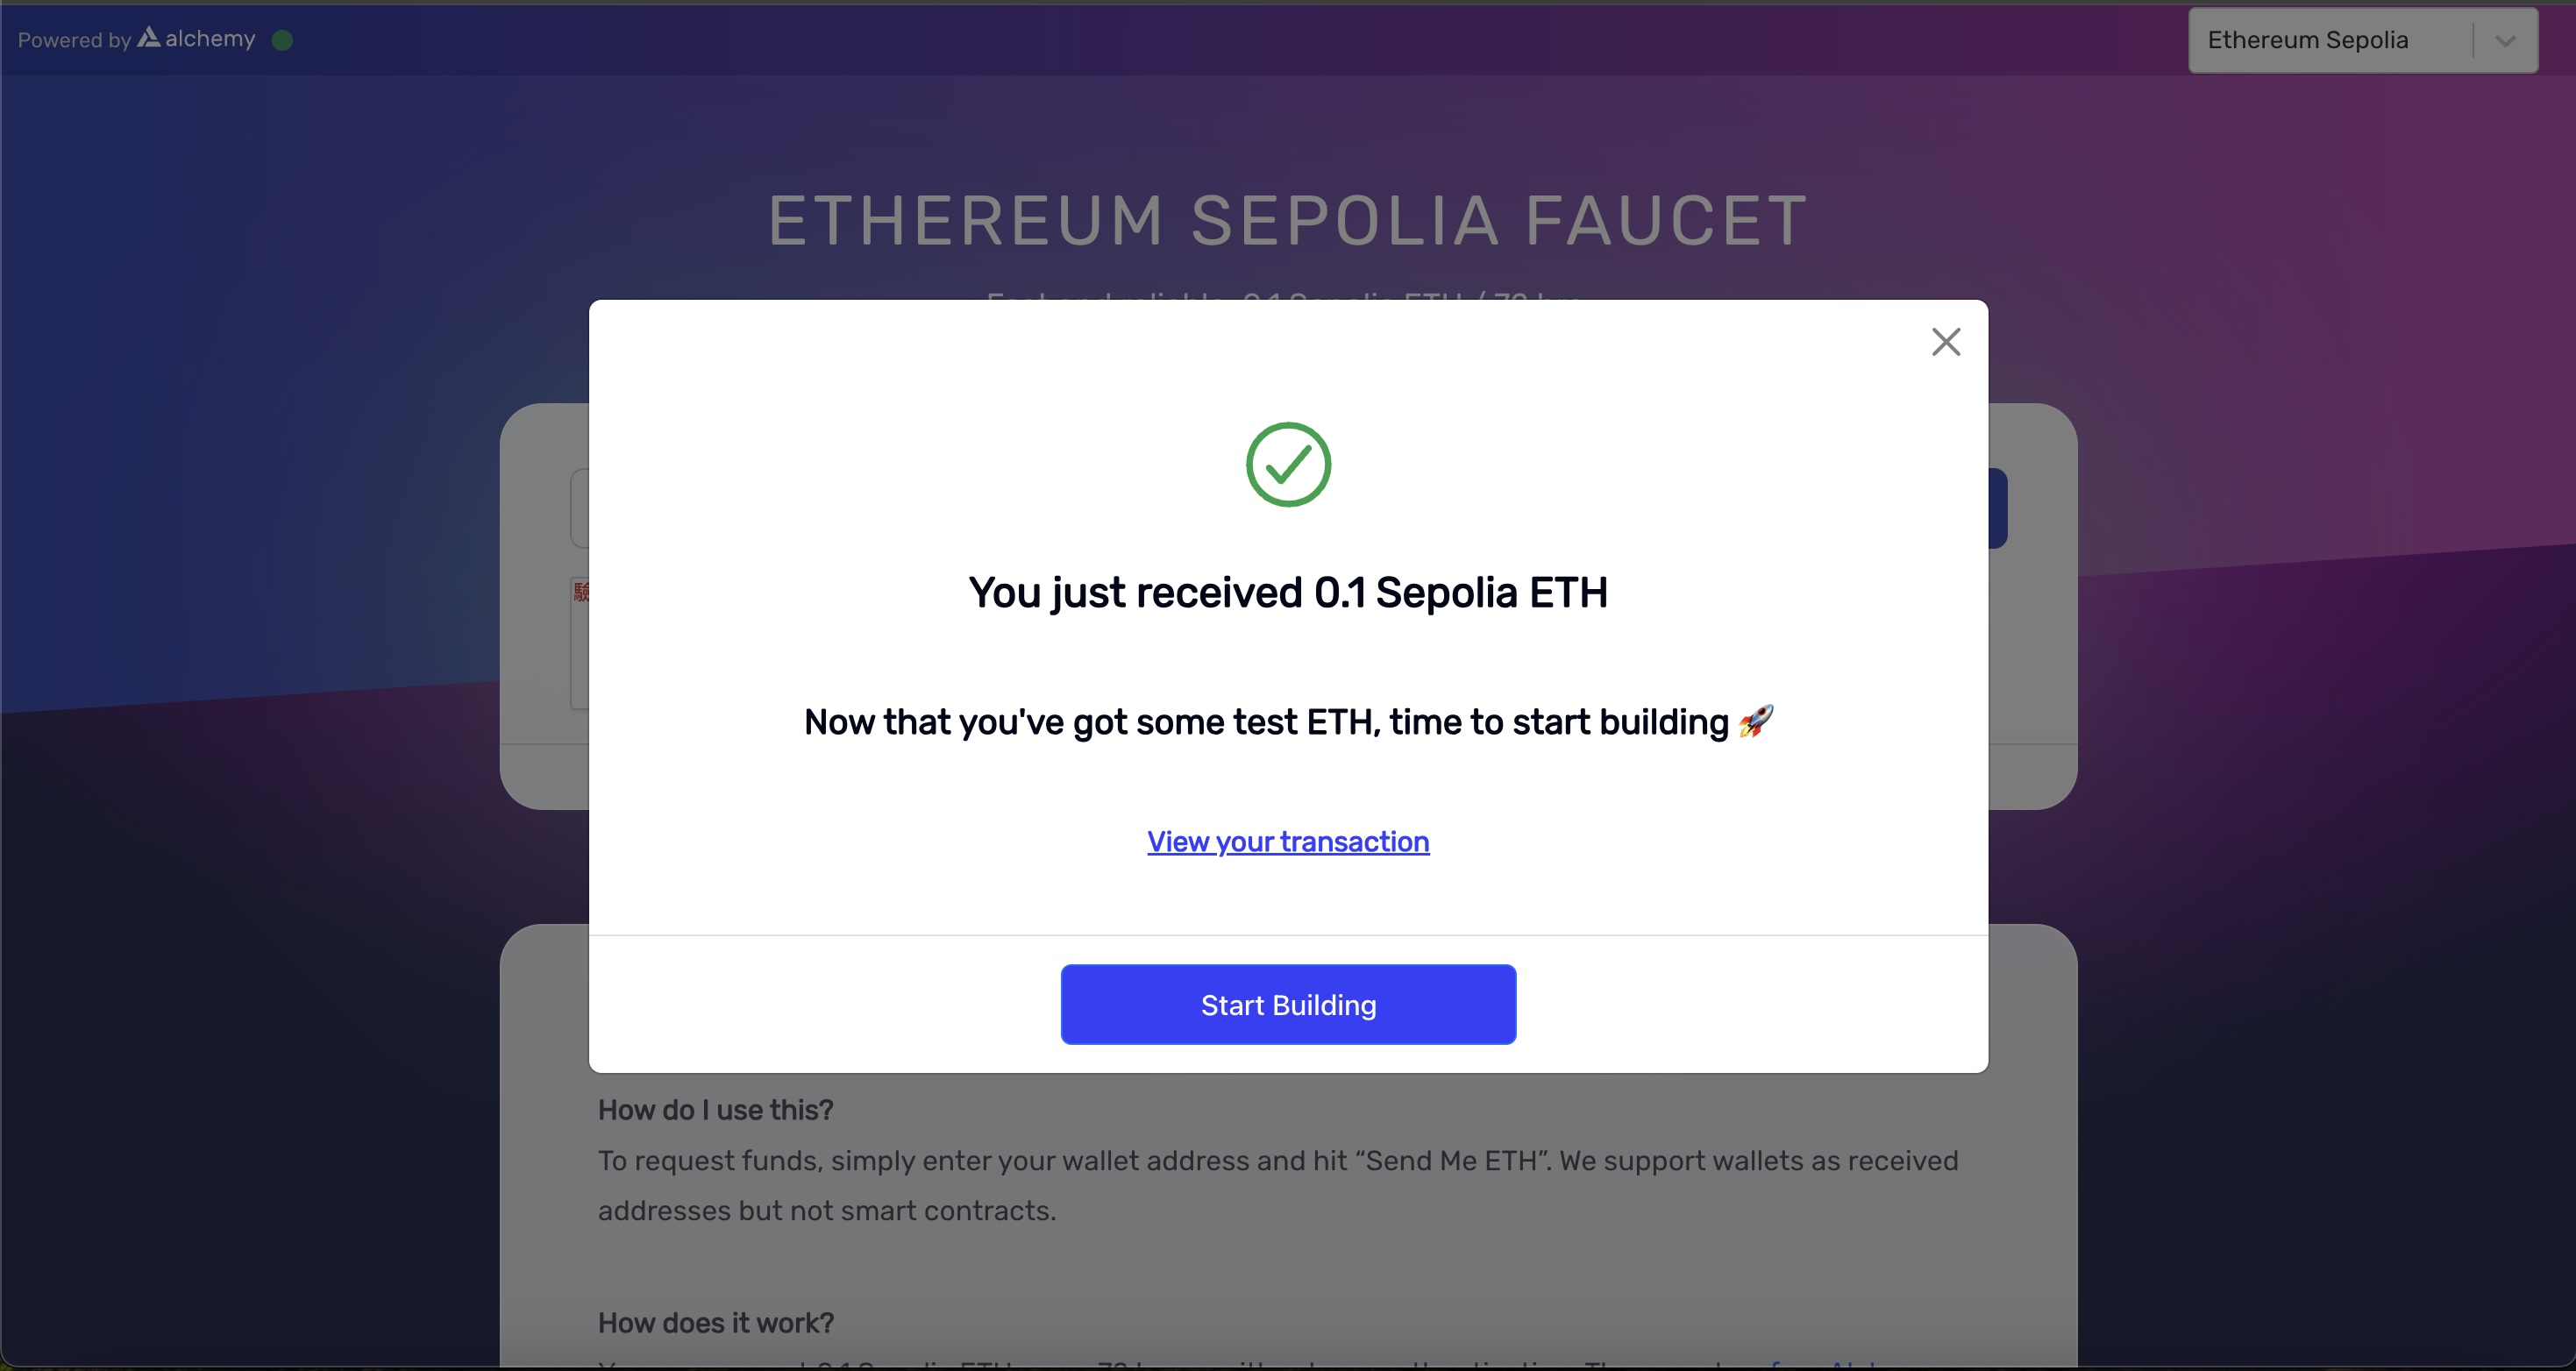

https://sepolia.etherscan.io/tx/0x1b6f495b5a8cfc0fb43e01f19ec1c245504637014f7c237a80fe81aab699f5a9

• ETH 線上編輯器- https://remix.ethereum.org

• NQU Meta 智能合約範例- https://github.com/ccwu0918/nqu_meta/blob/master/contracts/nqu_meta_nft.sol

• Nic Meta 智能合約範例- https://github.com/niclin/nic_meta/blob/master/contracts/nic_meta_nft.sol

In [ ]:
# @title
// Contract based on https://docs.openzeppelin.com/contracts/3.x/erc721
// SPDX-License-Identifier: MIT
pragma solidity ^0.8.0;

import "@openzeppelin/contracts/token/ERC721/extensions/ERC721Enumerable.sol";
import "@openzeppelin/contracts/access/Ownable.sol";
import "@openzeppelin/contracts/utils/Strings.sol";

contract NquMeta is ERC721Enumerable, Ownable {
    using Strings for uint256;

    bool public _isSaleActive = false;
    bool public _revealed = false;

    // Constants
    uint256 public constant MAX_SUPPLY = 10;
    uint256 public mintPrice = 0.001 ether;
    uint256 public maxBalance = 1;
    uint256 public maxMint = 1;

    string baseURI;
    string public notRevealedUri;
    string public baseExtension = ".json";

    mapping(uint256 => string) private _tokenURIs;

    constructor(string memory initBaseURI, string memory initNotRevealedUri)
        ERC721("NQU Meta", "NQUCoin")
        Ownable(msg.sender) // <-- Add this line
    {
        setBaseURI(initBaseURI);
        setNotRevealedURI(initNotRevealedUri);
    }

    function mintNquMeta(uint256 tokenQuantity) public payable {
        require(
            totalSupply() + tokenQuantity <= MAX_SUPPLY,
            "Sale would exceed max supply"
        );
        require(_isSaleActive, "Sale must be active to mint NQU Metas");
        require(
            balanceOf(msg.sender) + tokenQuantity <= maxBalance,
            "Sale would exceed max balance"
        );
        require(
            tokenQuantity * mintPrice <= msg.value,
            "Not enough ether sent"
        );
        require(tokenQuantity <= maxMint, "Can only mint 1 tokens at a time");

        _mintNquMeta(tokenQuantity);
    }

    function _mintNquMeta(uint256 tokenQuantity) internal {
        for (uint256 i = 0; i < tokenQuantity; i++) {
            uint256 mintIndex = totalSupply();
            if (totalSupply() < MAX_SUPPLY) {
                _safeMint(msg.sender, mintIndex);
            }
        }
    }

    function tokenURI(uint256 tokenId)
        public
        view
        virtual
        override
        returns (string memory)
    {
        require(
            _ownerOf(tokenId) != address(0),
            "ERC721Metadata: URI query for nonexistent token"
        );

        if (_revealed == false) {
            return notRevealedUri;
        }

        string memory _tokenURI = _tokenURIs[tokenId];
        string memory base = _baseURI();

        // If there is no base URI, return the token URI.
        if (bytes(base).length == 0) {
            return _tokenURI;
        }
        // If both are set, concatenate the baseURI and tokenURI (via abi.encodePacked).
        if (bytes(_tokenURI).length > 0) {
            return string(abi.encodePacked(base, _tokenURI));
        }
        // If there is a baseURI but no tokenURI, concatenate the tokenID to the baseURI.
        return
            string(abi.encodePacked(base, tokenId.toString(), baseExtension));
    }

    // internal
    function _baseURI() internal view virtual override returns (string memory) {
        return baseURI;
    }

    //only owner
    function flipSaleActive() public onlyOwner {
        _isSaleActive = !_isSaleActive;
    }

    function flipReveal() public onlyOwner {
        _revealed = !_revealed;
    }

    function setMintPrice(uint256 _mintPrice) public onlyOwner {
        mintPrice = _mintPrice;
    }

    function setNotRevealedURI(string memory _notRevealedURI) public onlyOwner {
        notRevealedUri = _notRevealedURI;
    }

    function setBaseURI(string memory _newBaseURI) public onlyOwner {
        baseURI = _newBaseURI;
    }

    function setBaseExtension(string memory _newBaseExtension)
        public
        onlyOwner
    {
        baseExtension = _newBaseExtension;
    }

    function setMaxBalance(uint256 _maxBalance) public onlyOwner {
        maxBalance = _maxBalance;
    }

    function setMaxMint(uint256 _maxMint) public onlyOwner {
        maxMint = _maxMint;
    }

    function withdraw(address to) public onlyOwner {
        uint256 balance = address(this).balance;
        payable(to).transfer(balance);
    }
}

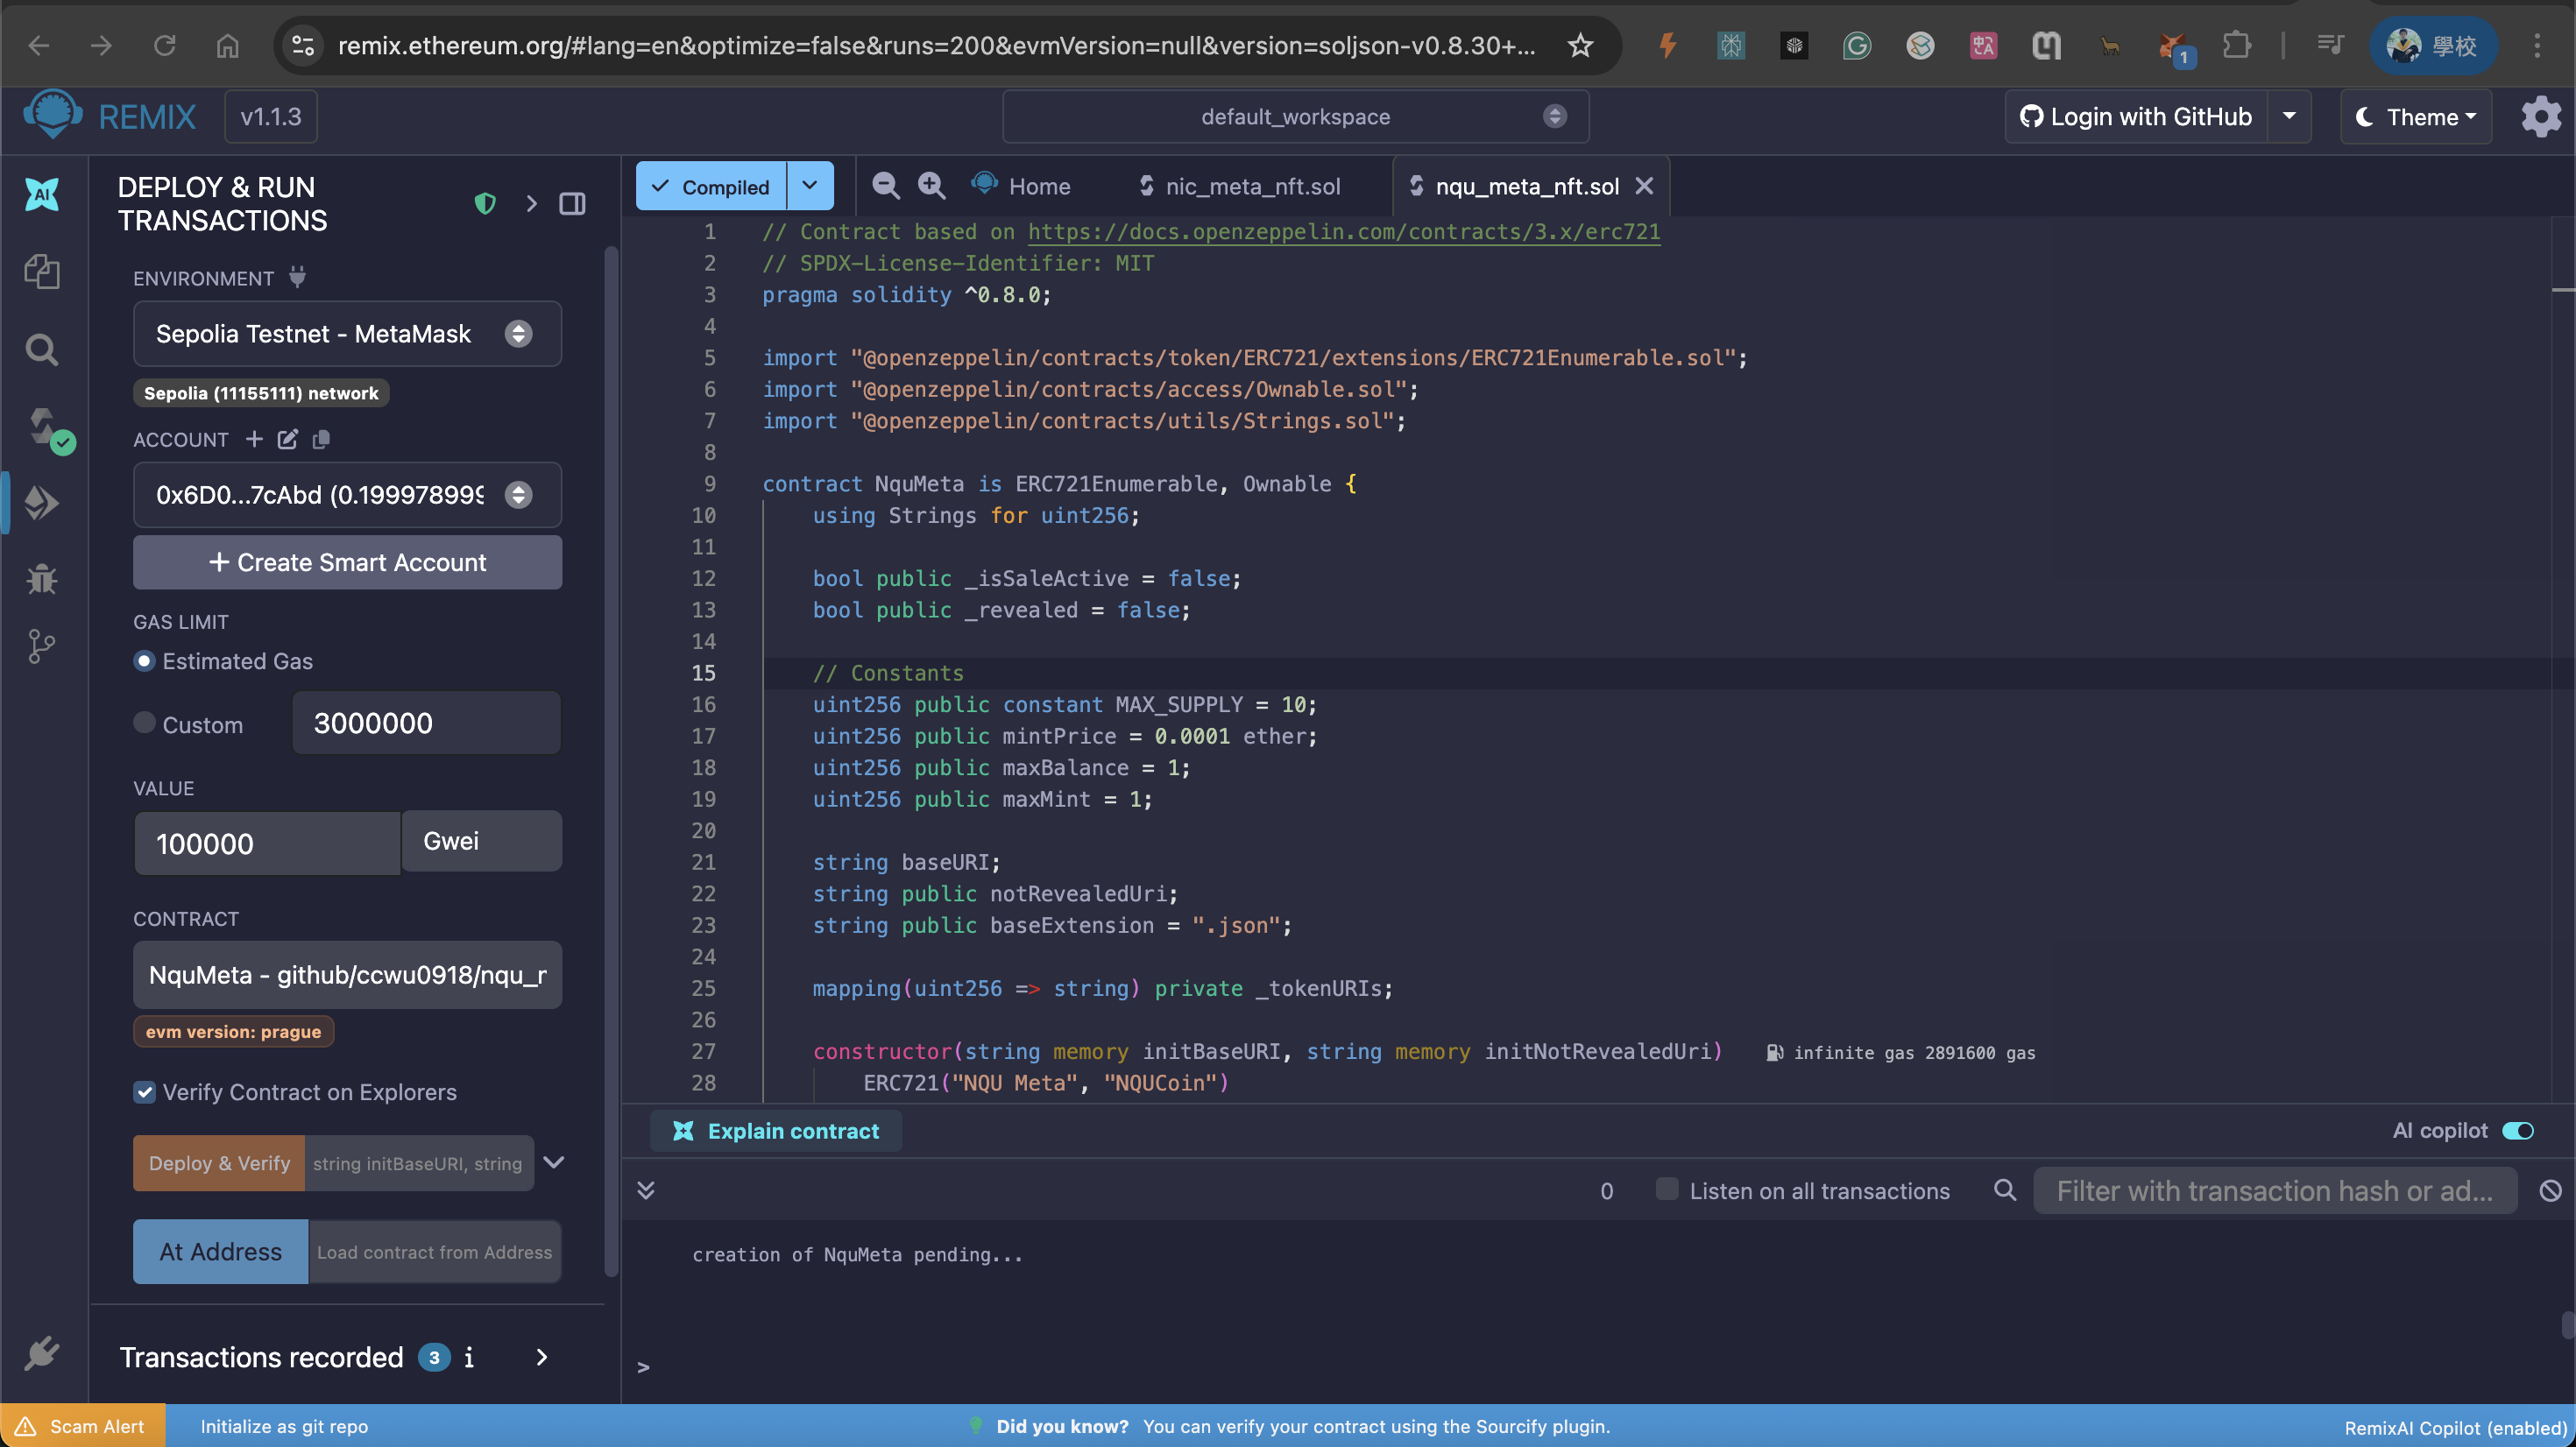

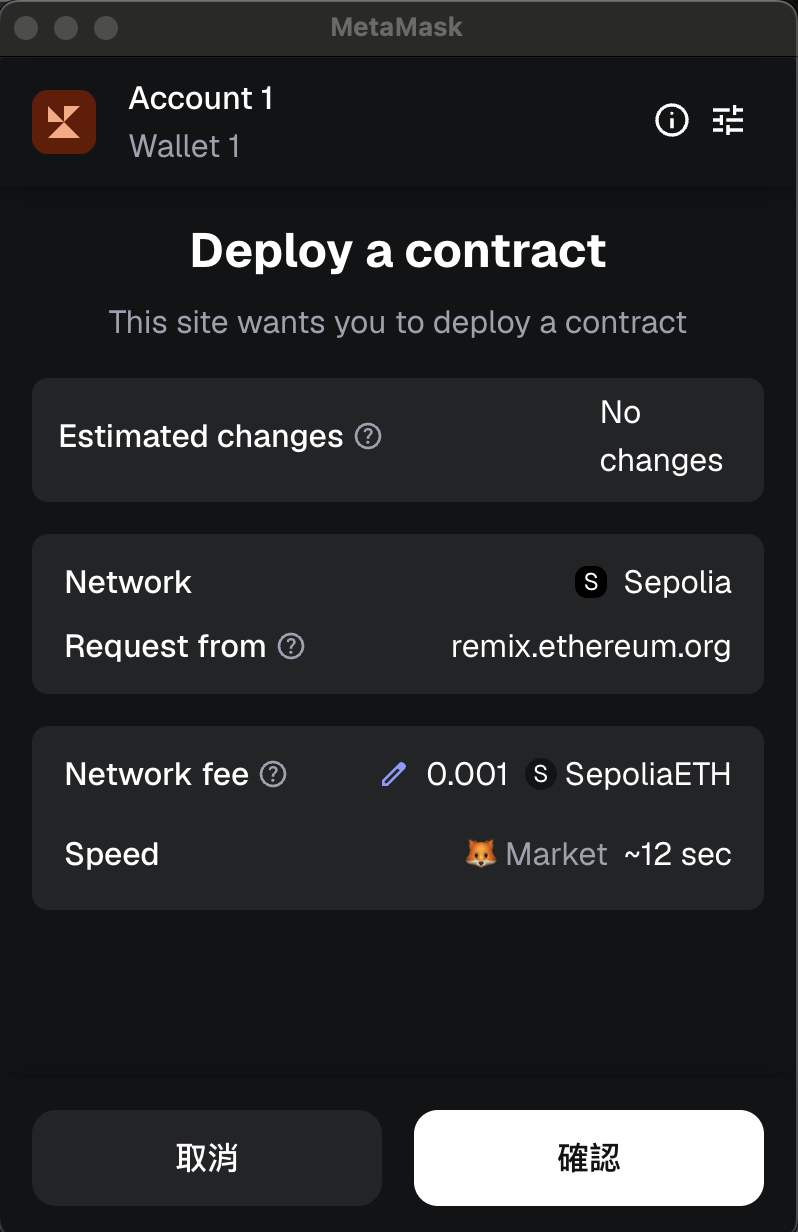

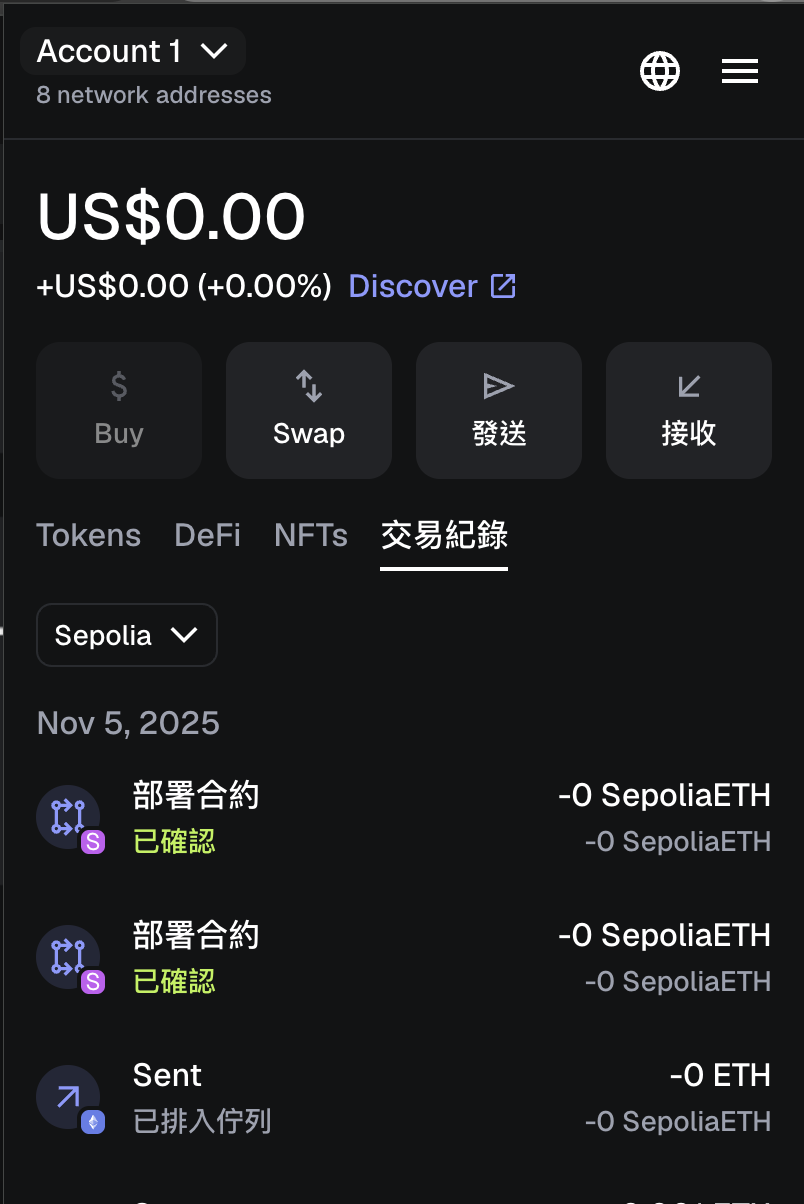

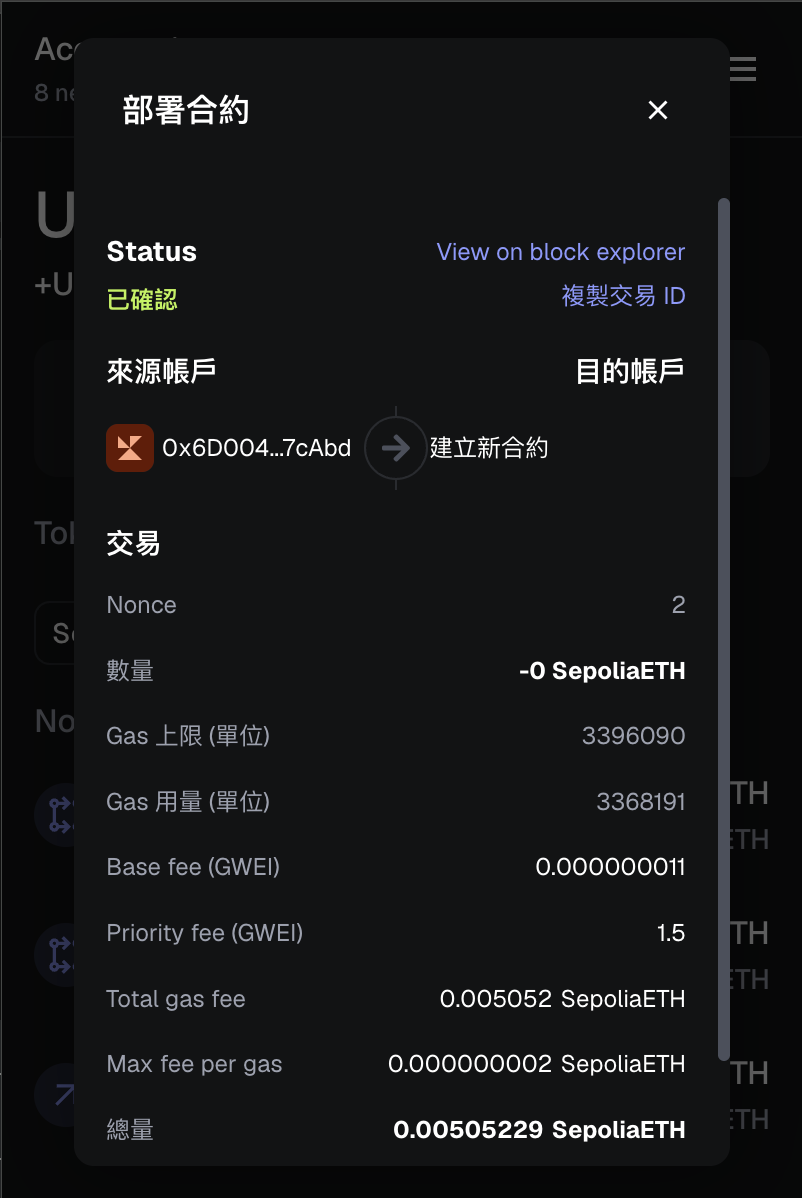

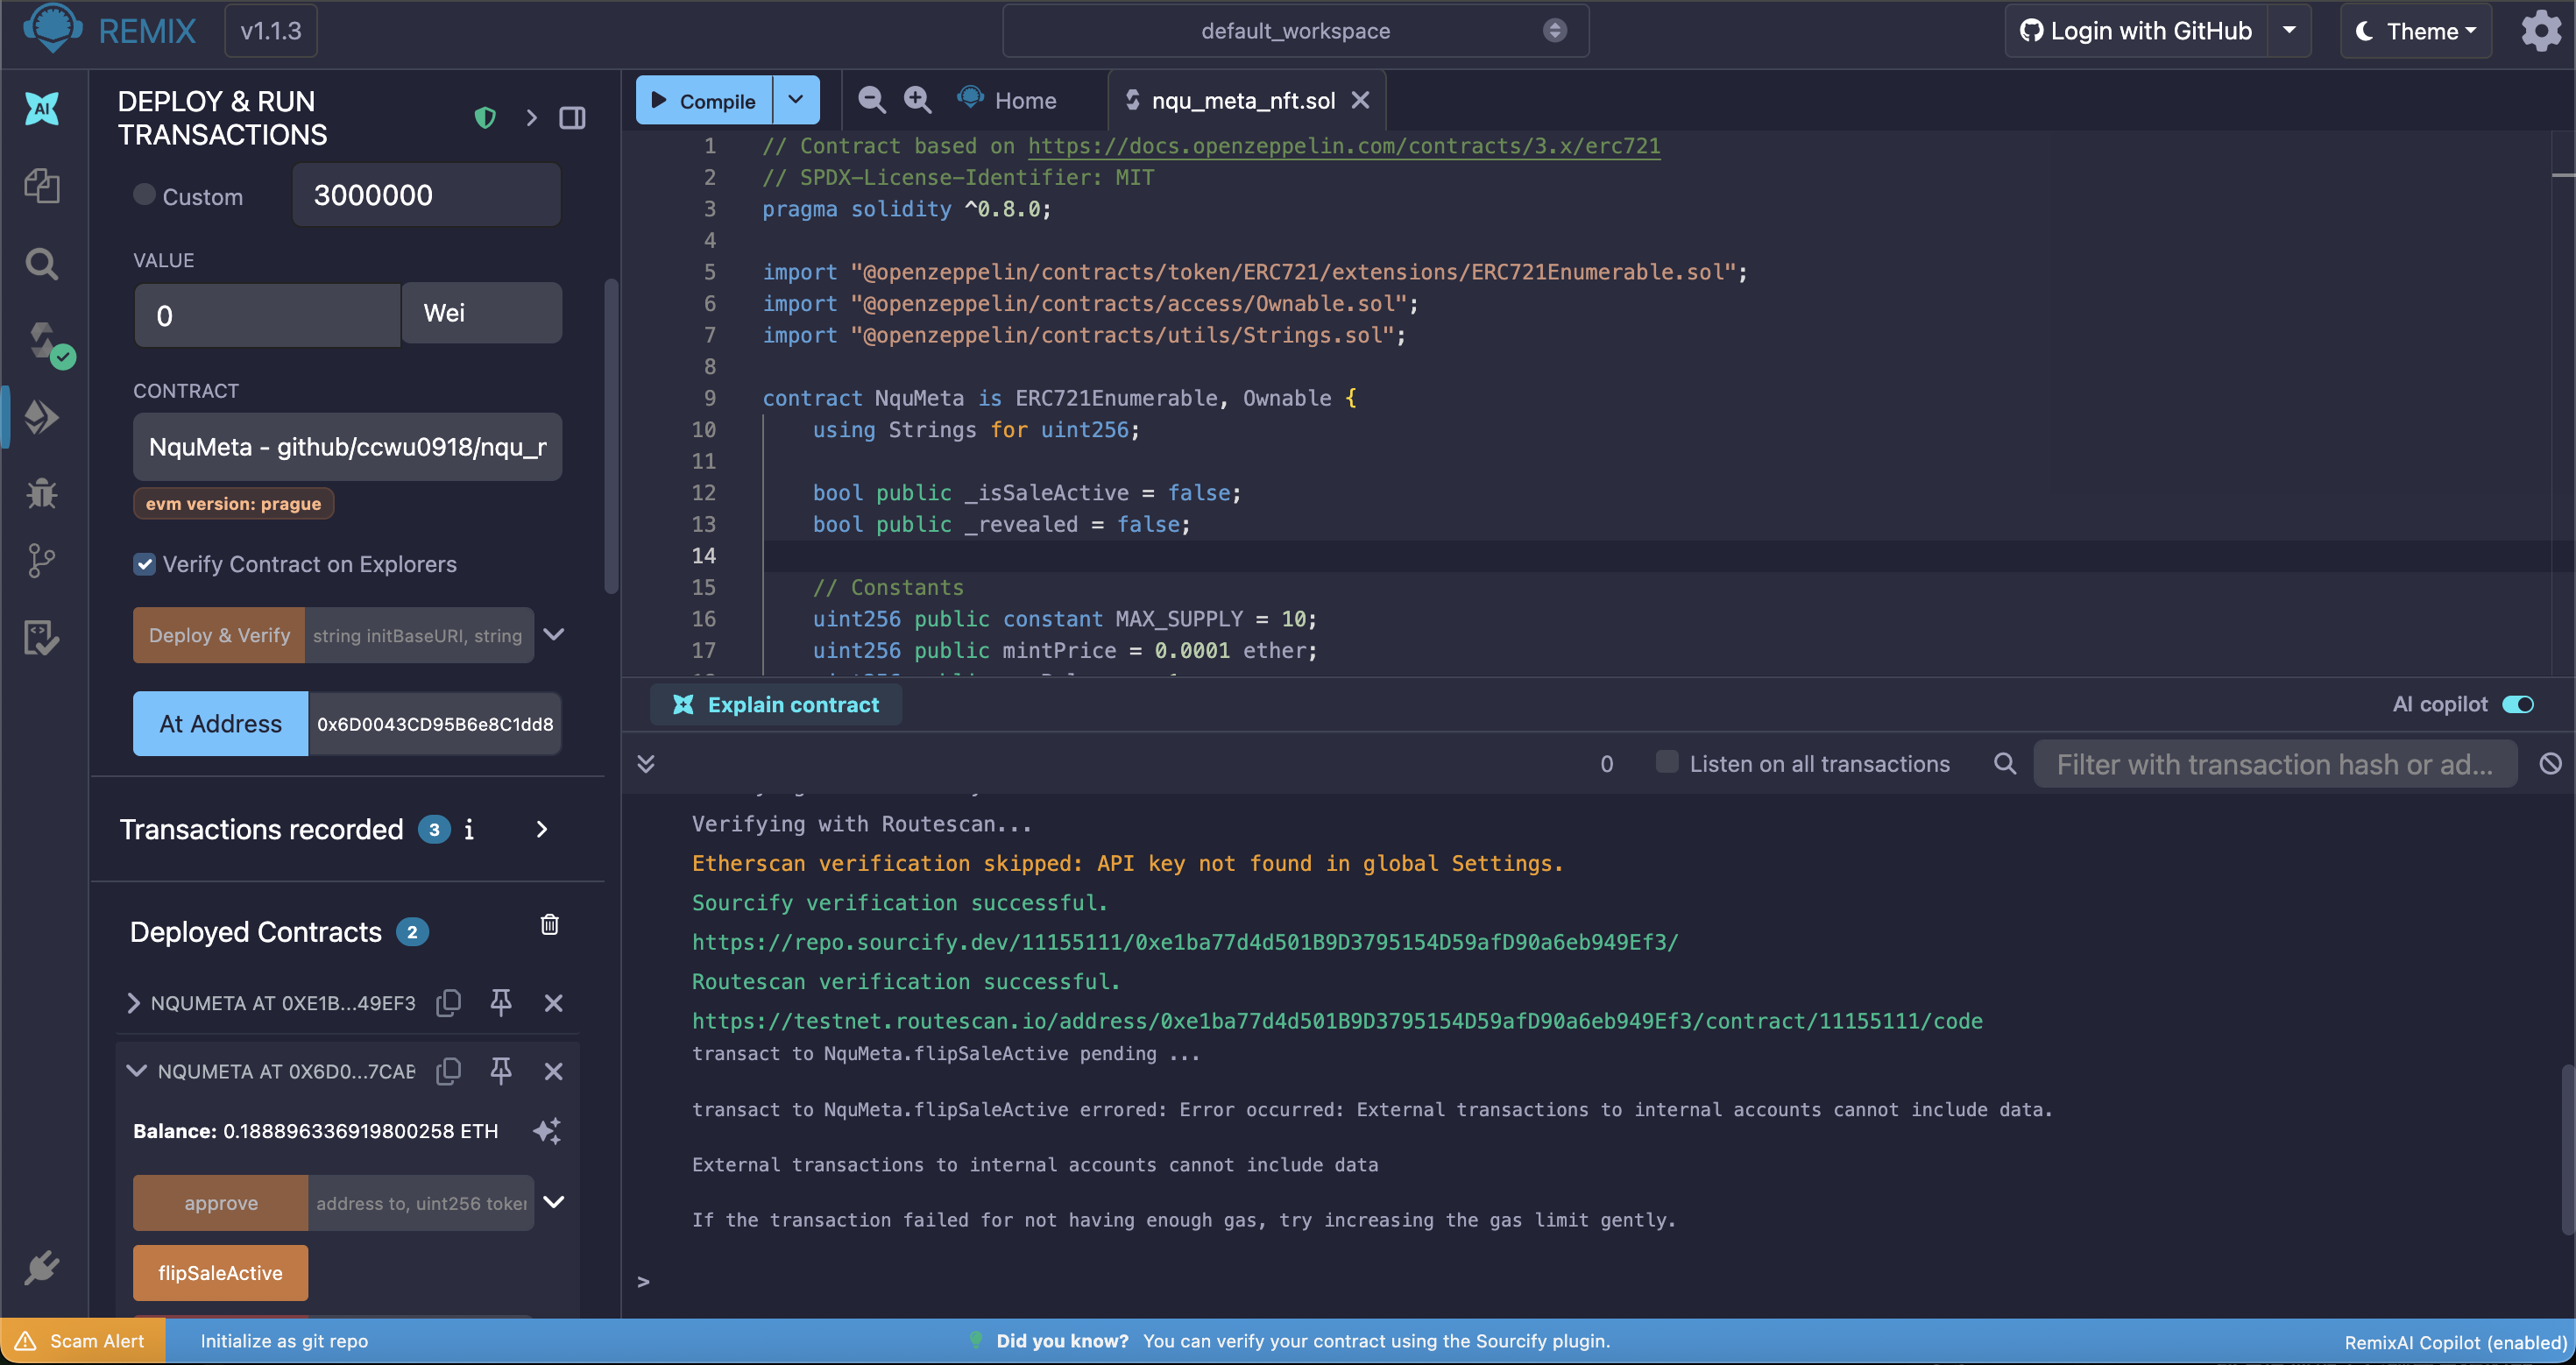

• ETH 轉Gwei - https://eth-converter.com

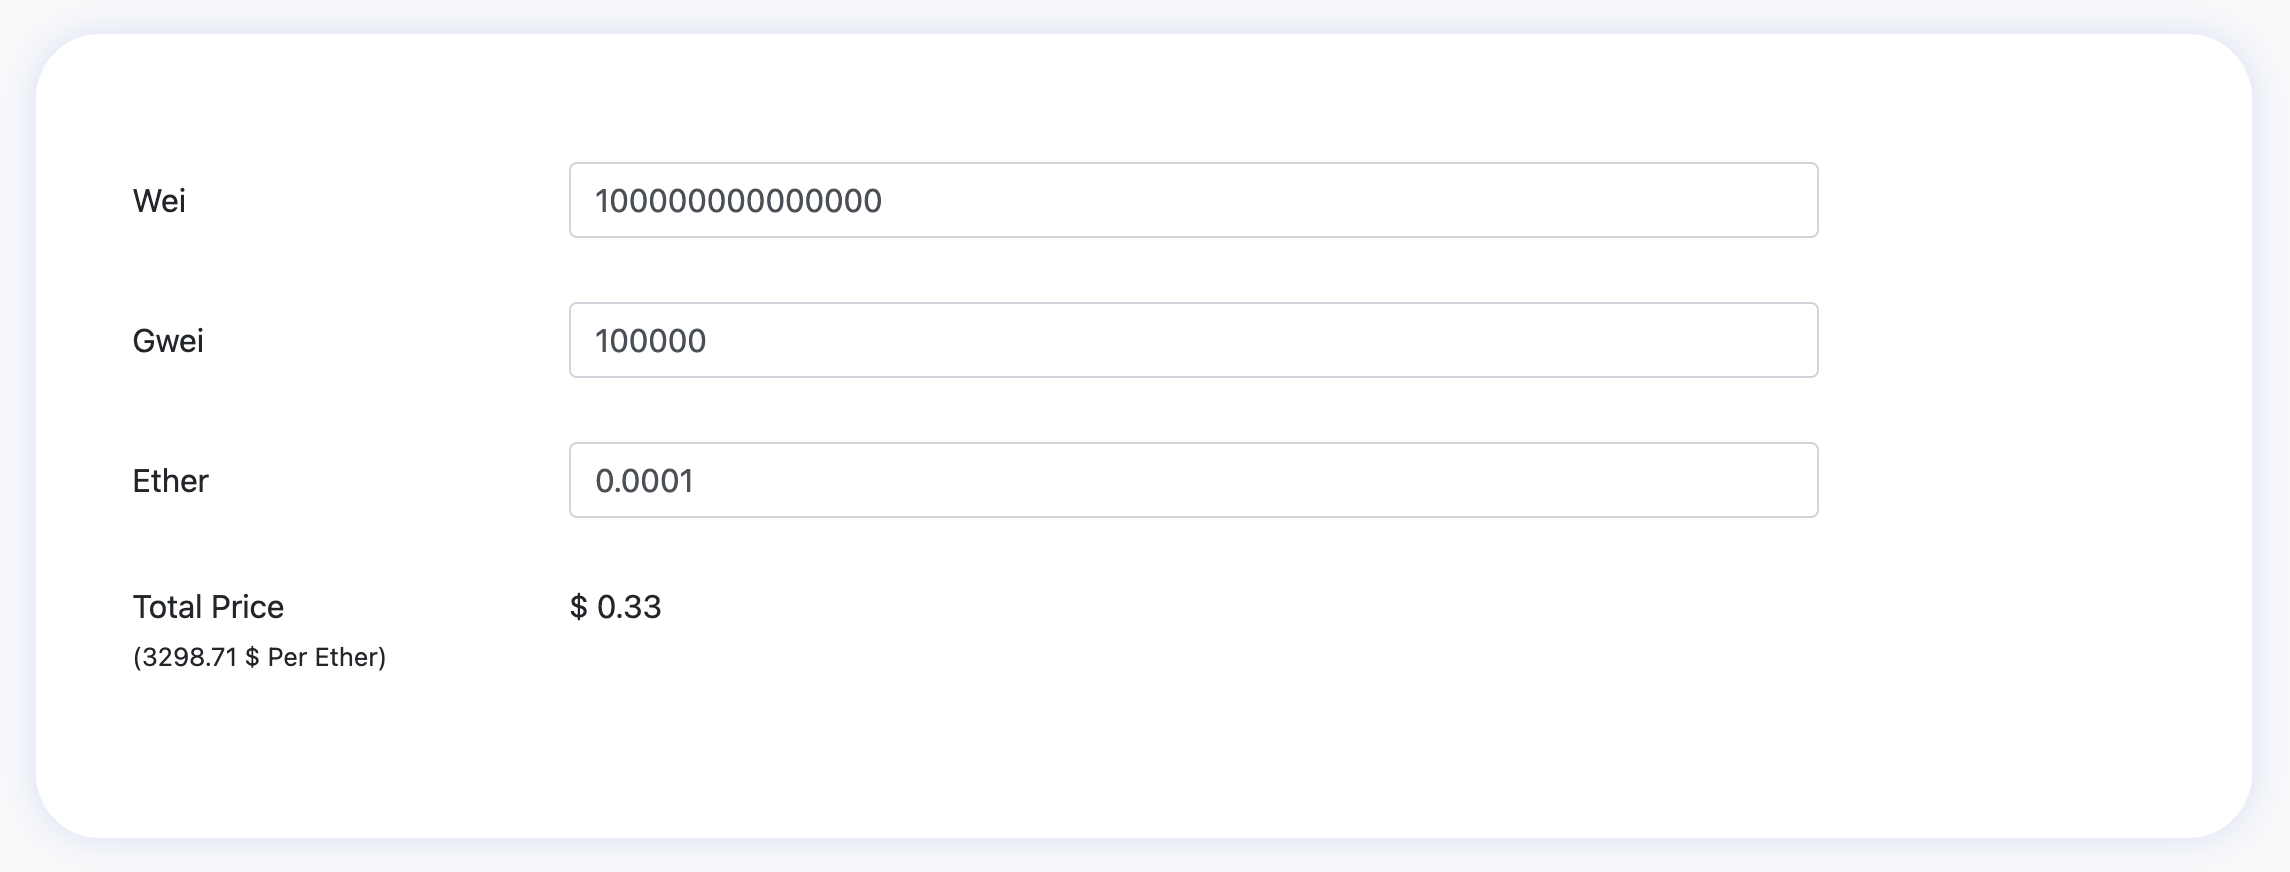

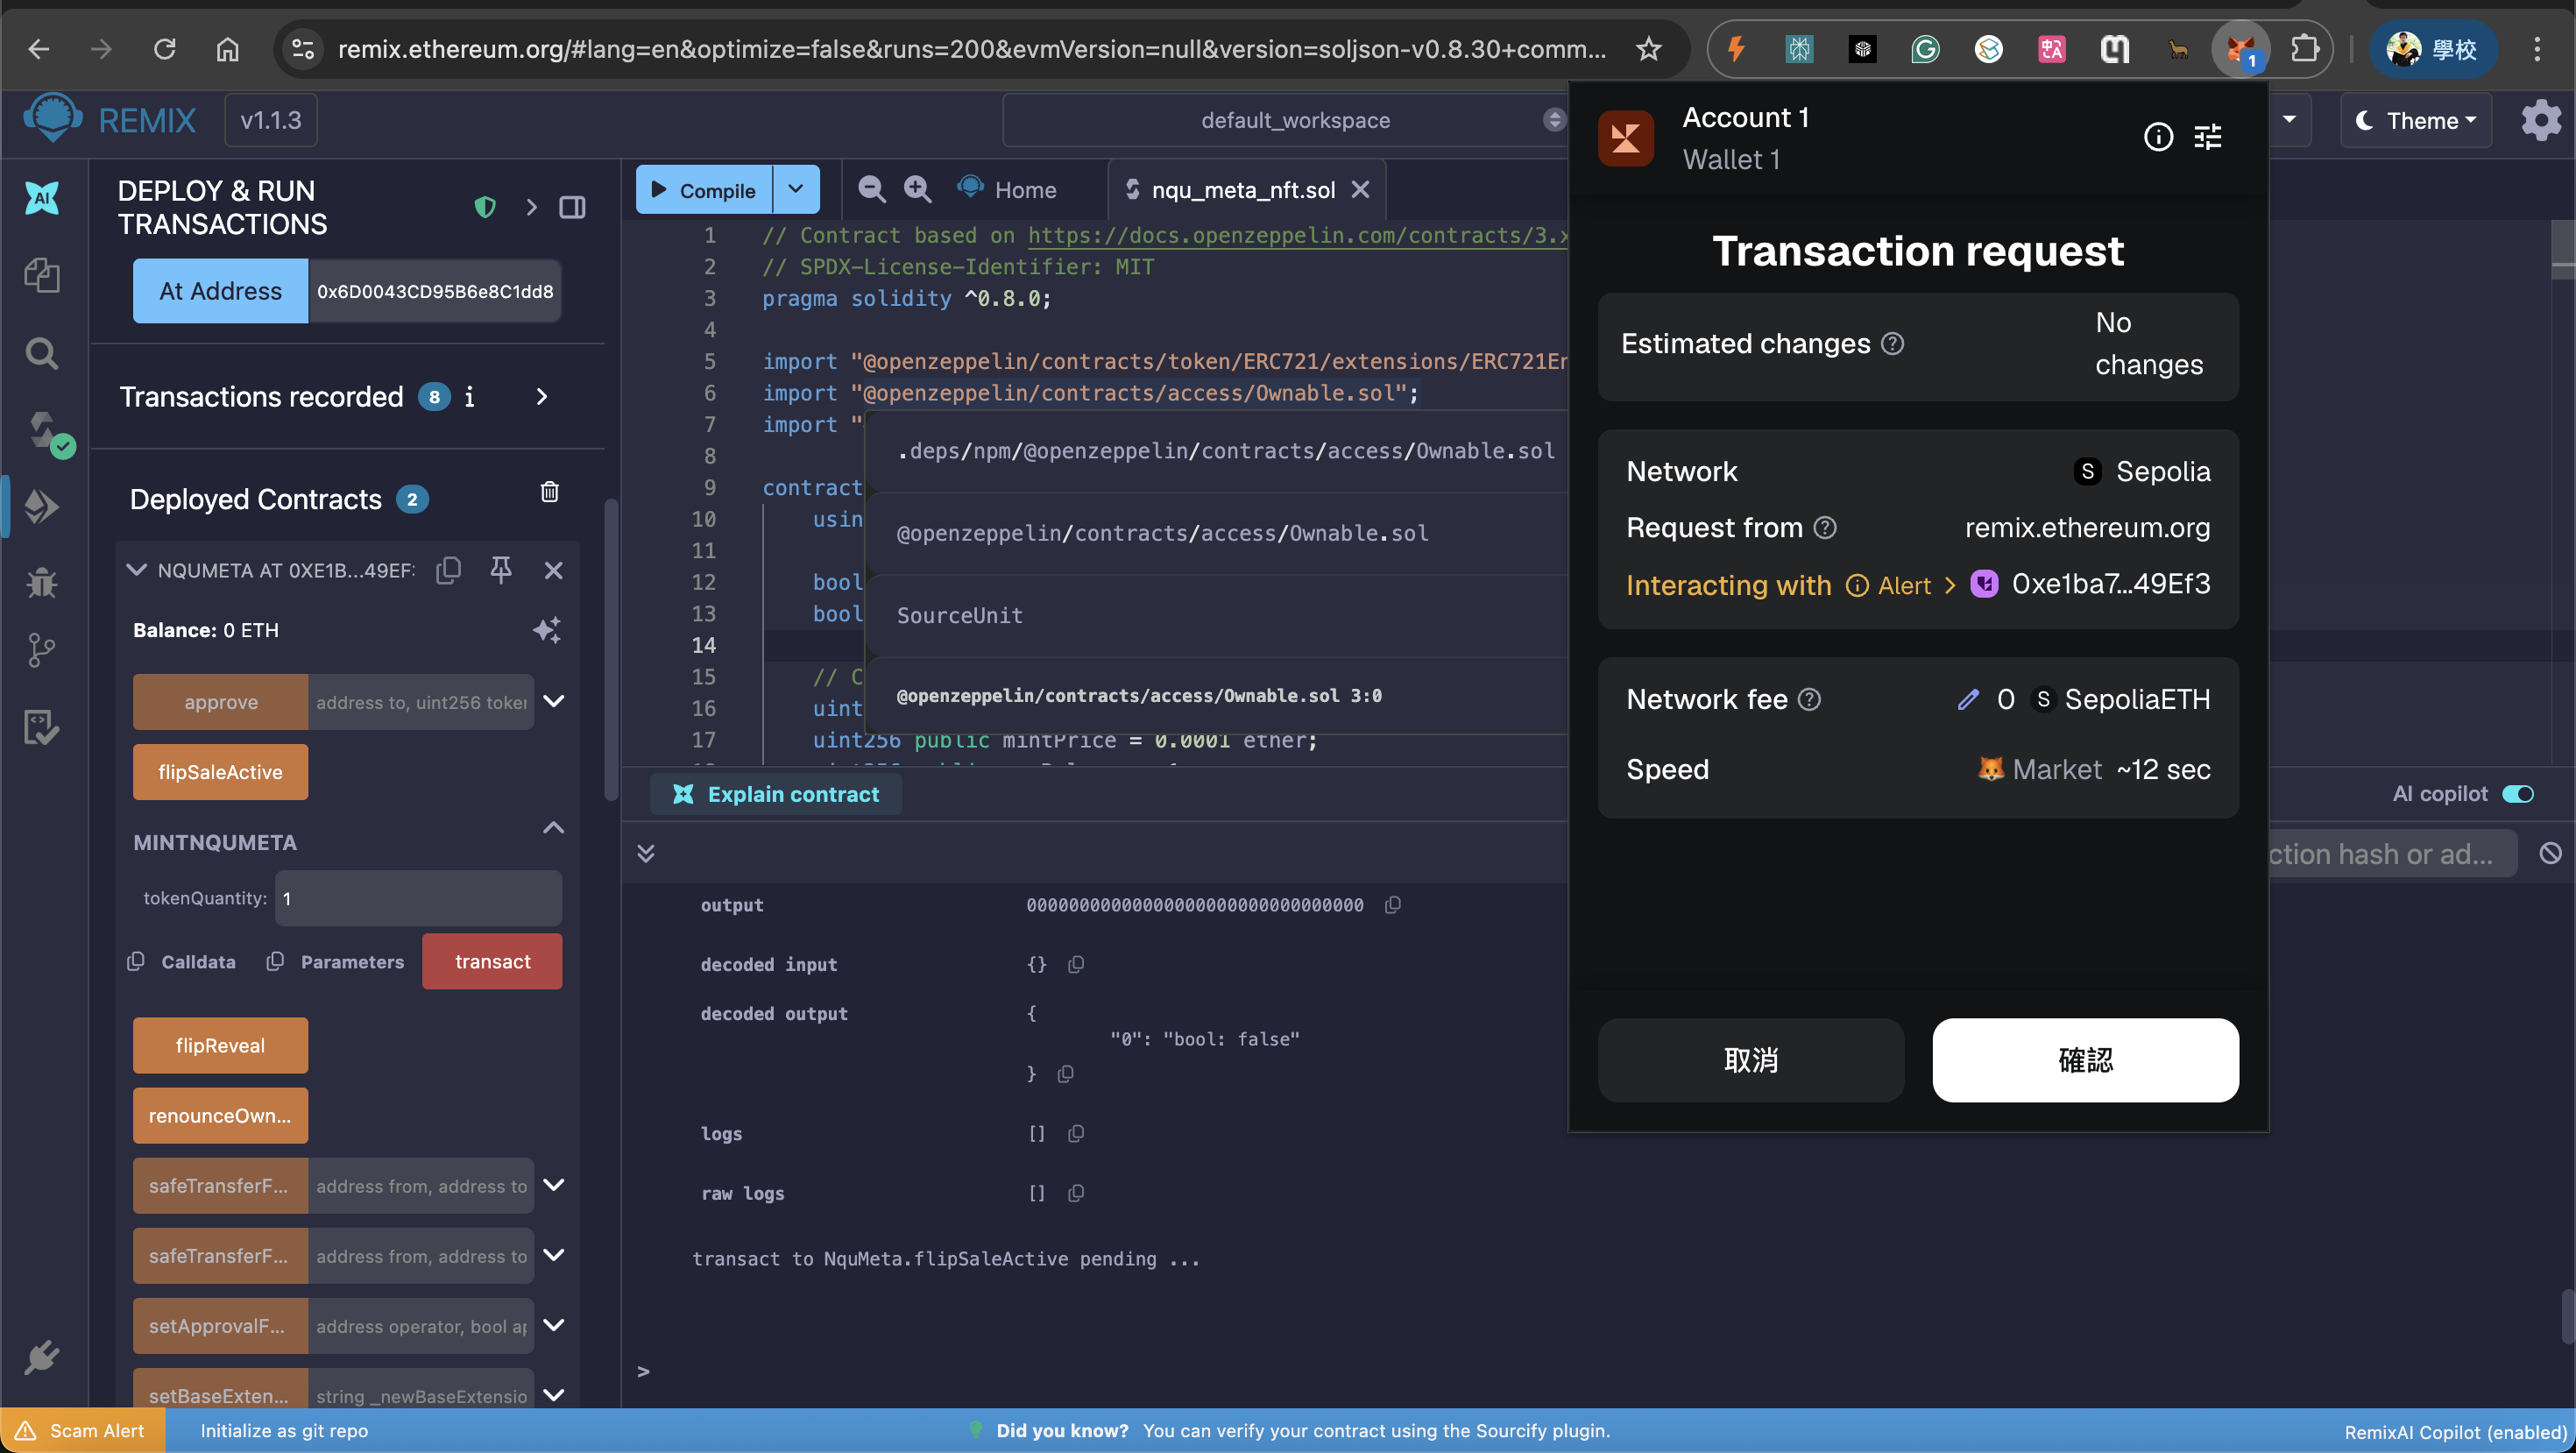

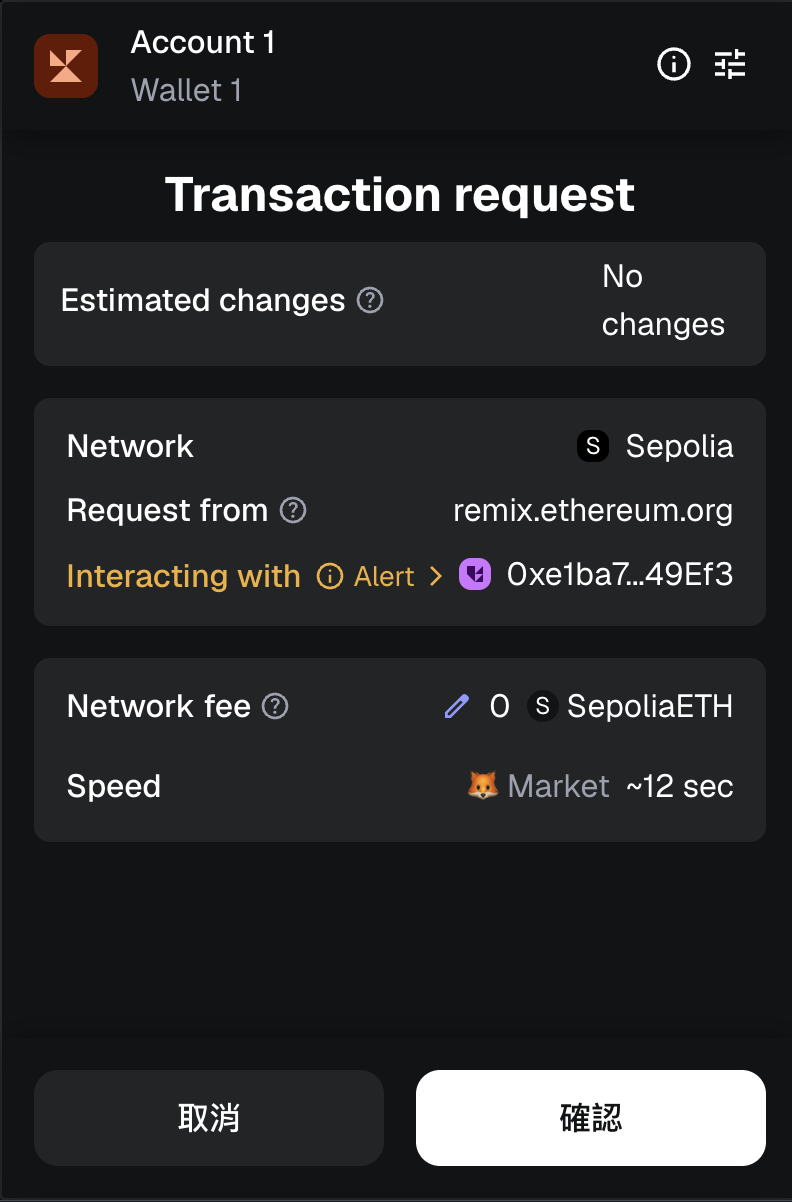

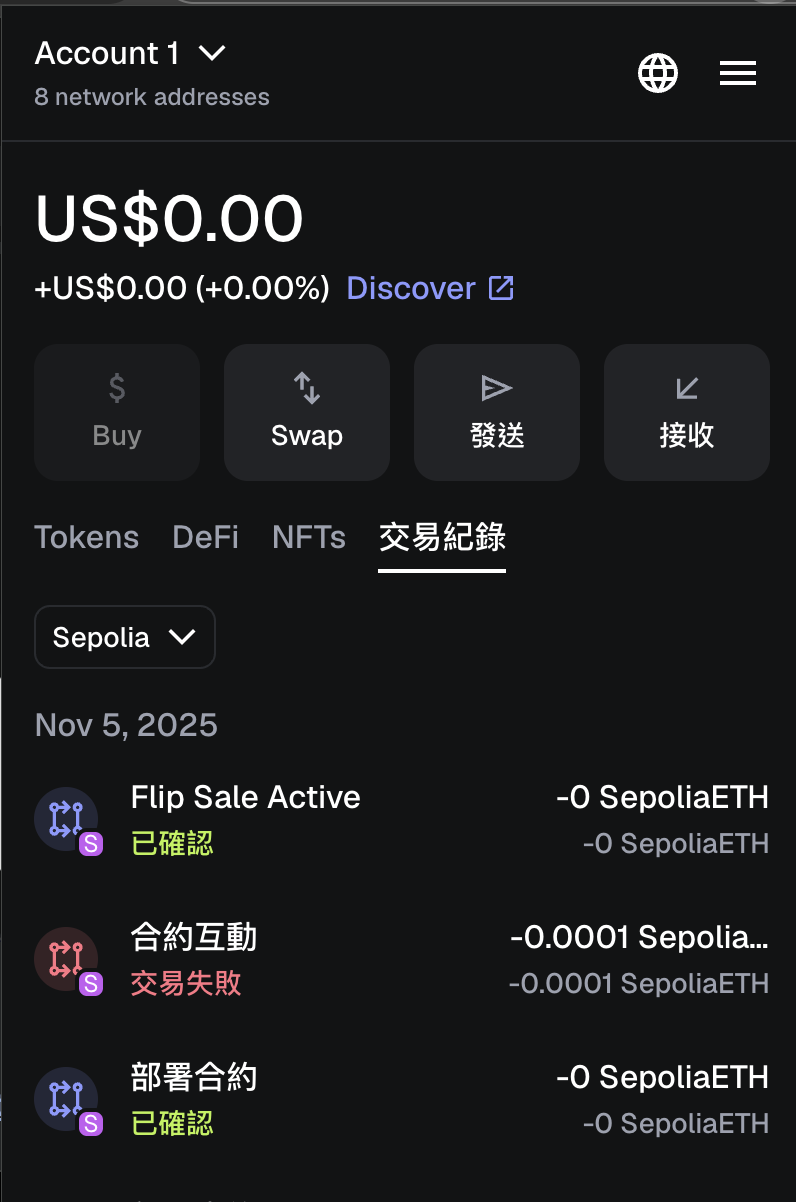

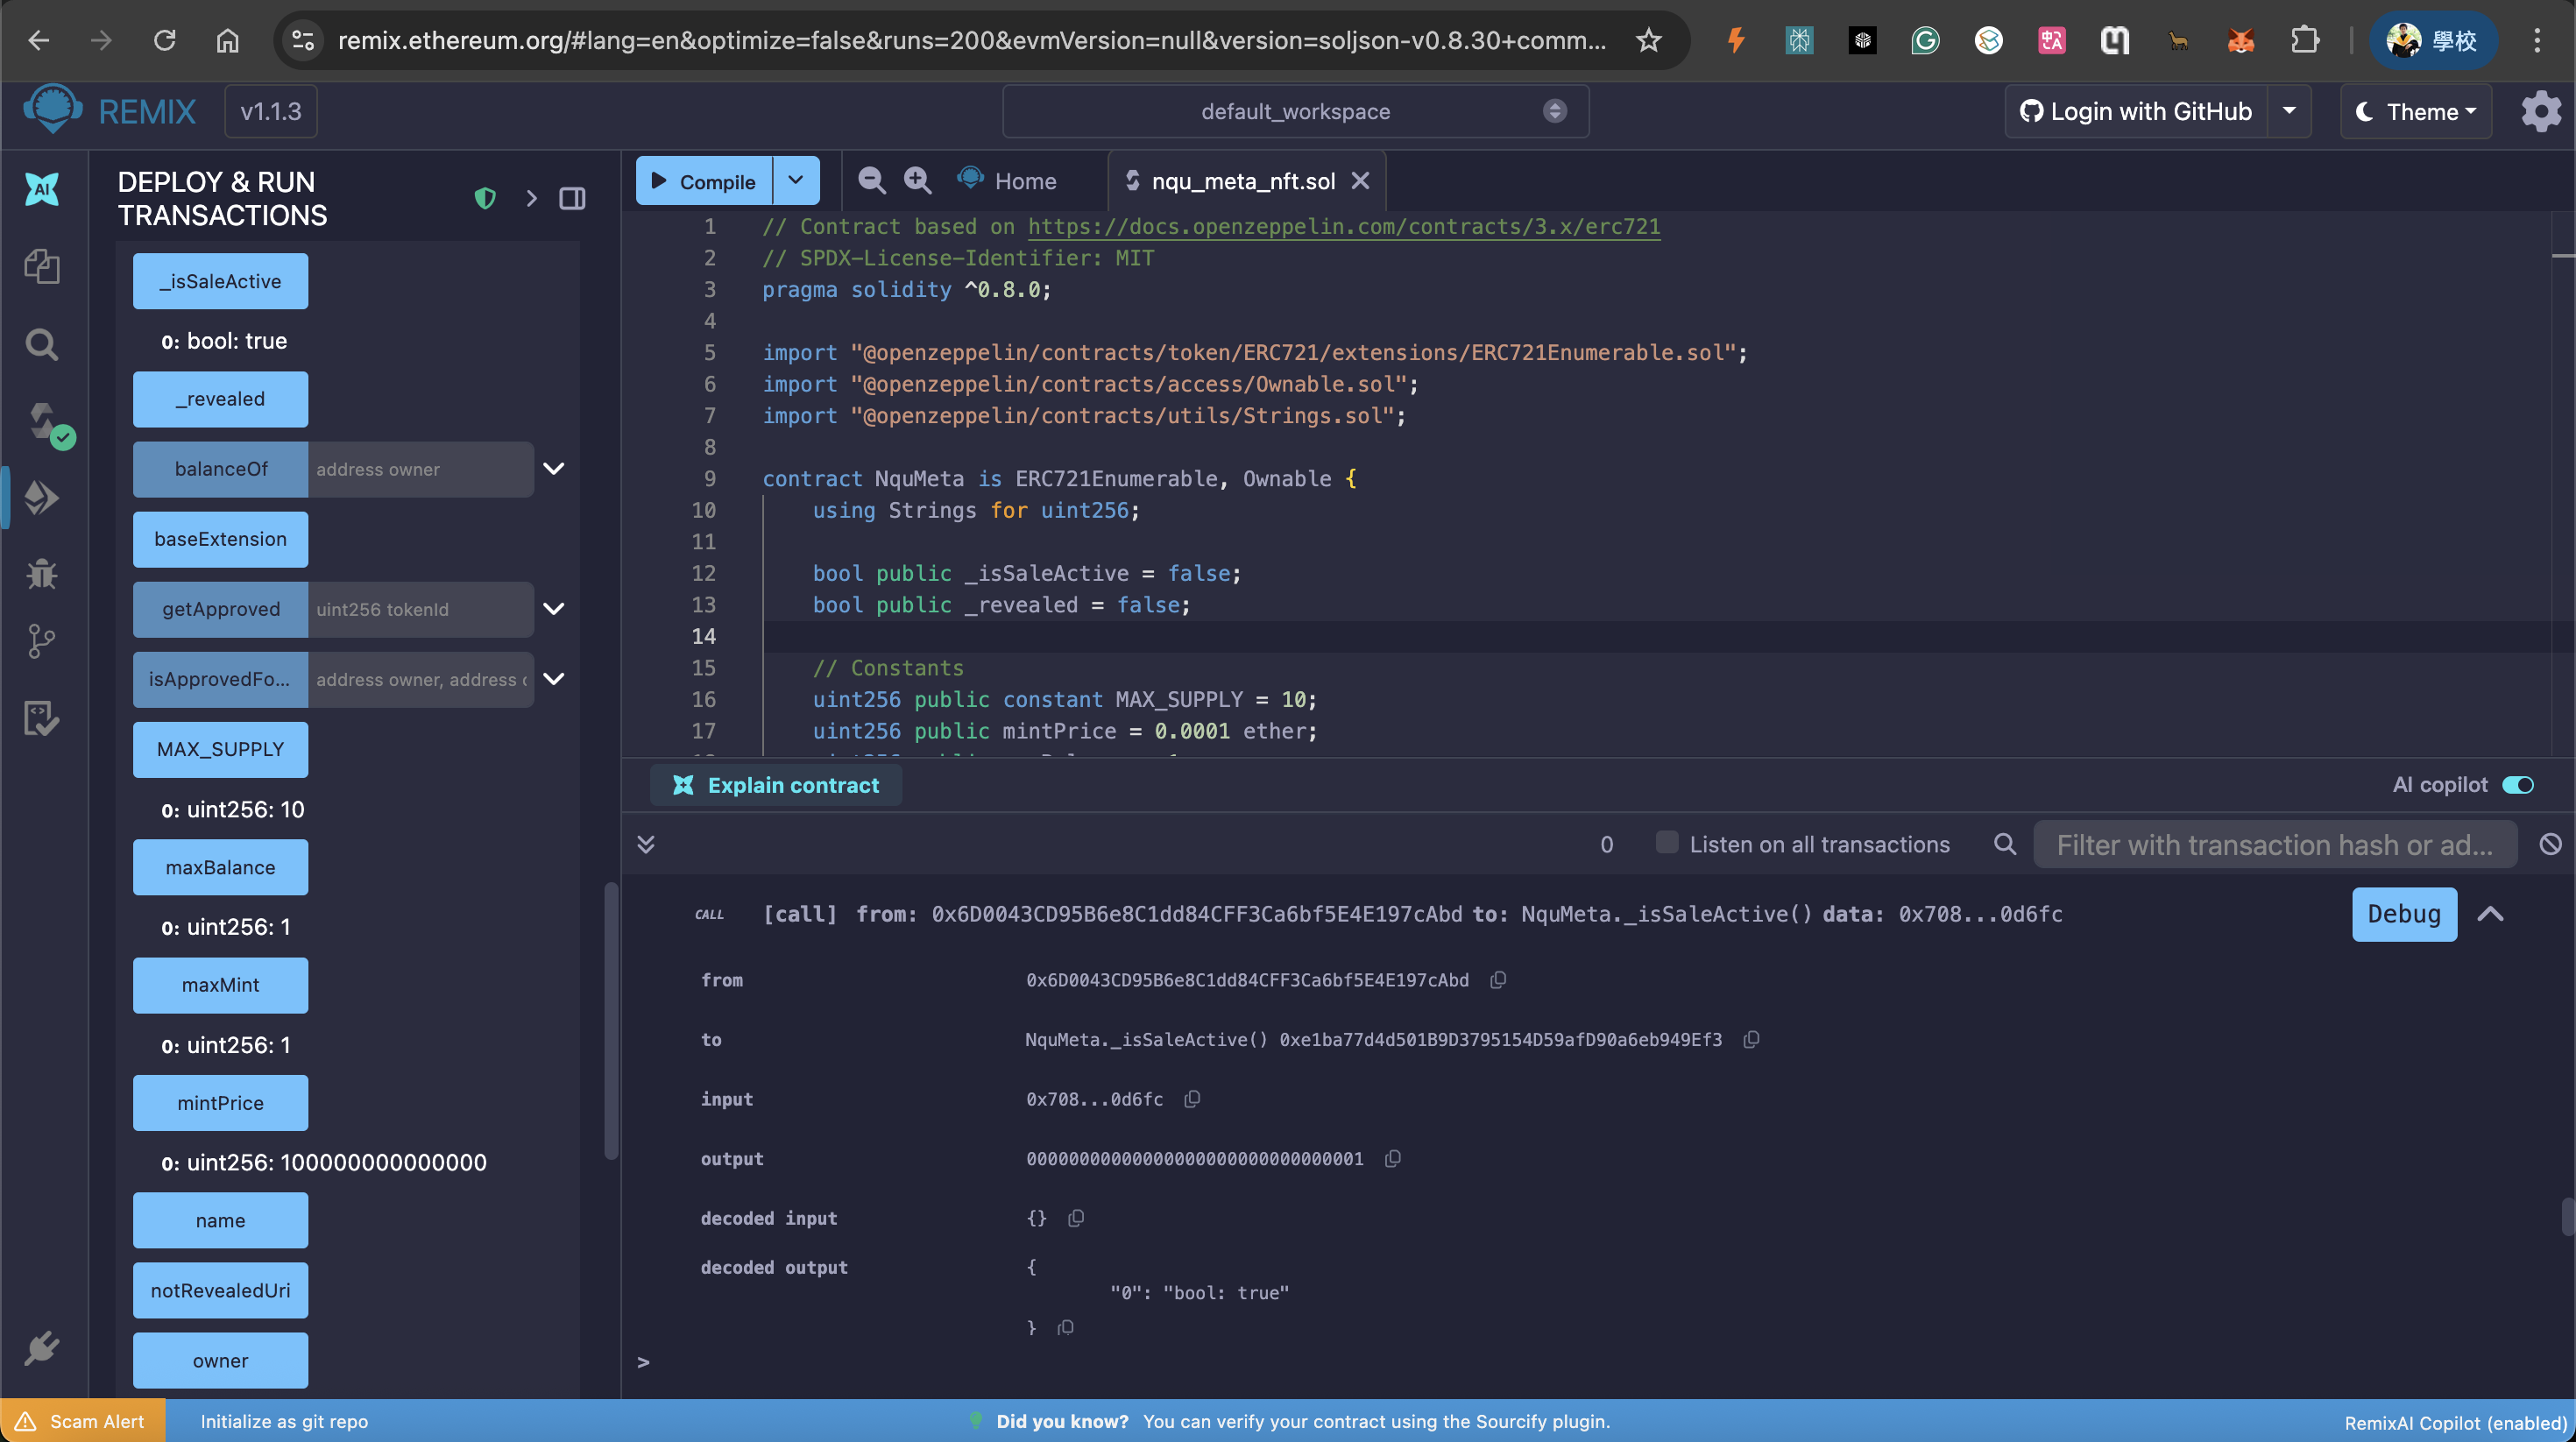

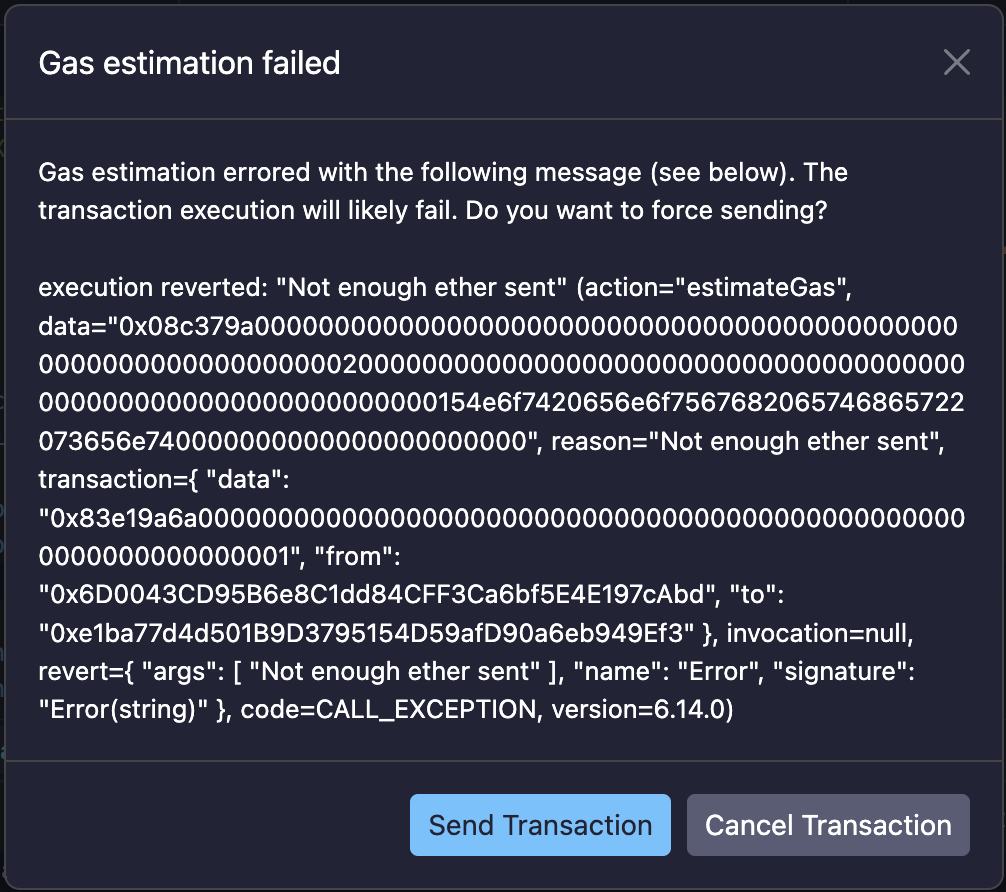

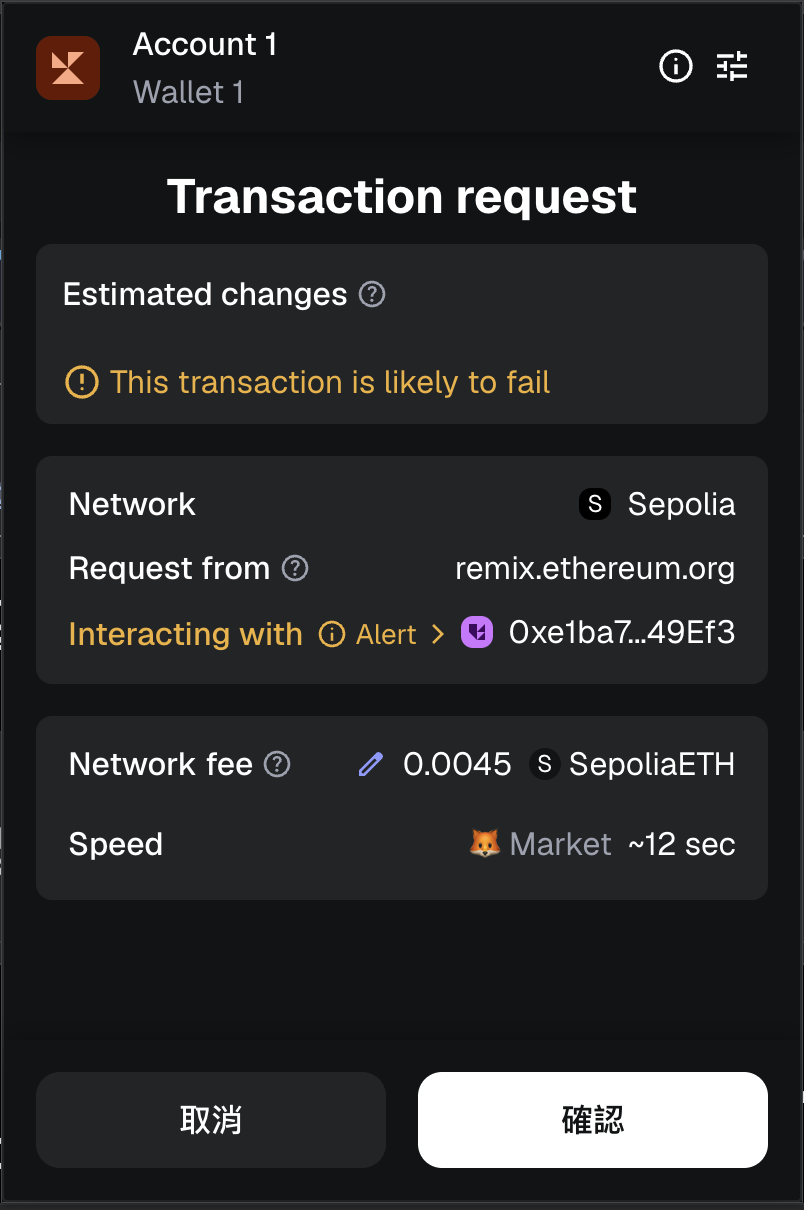

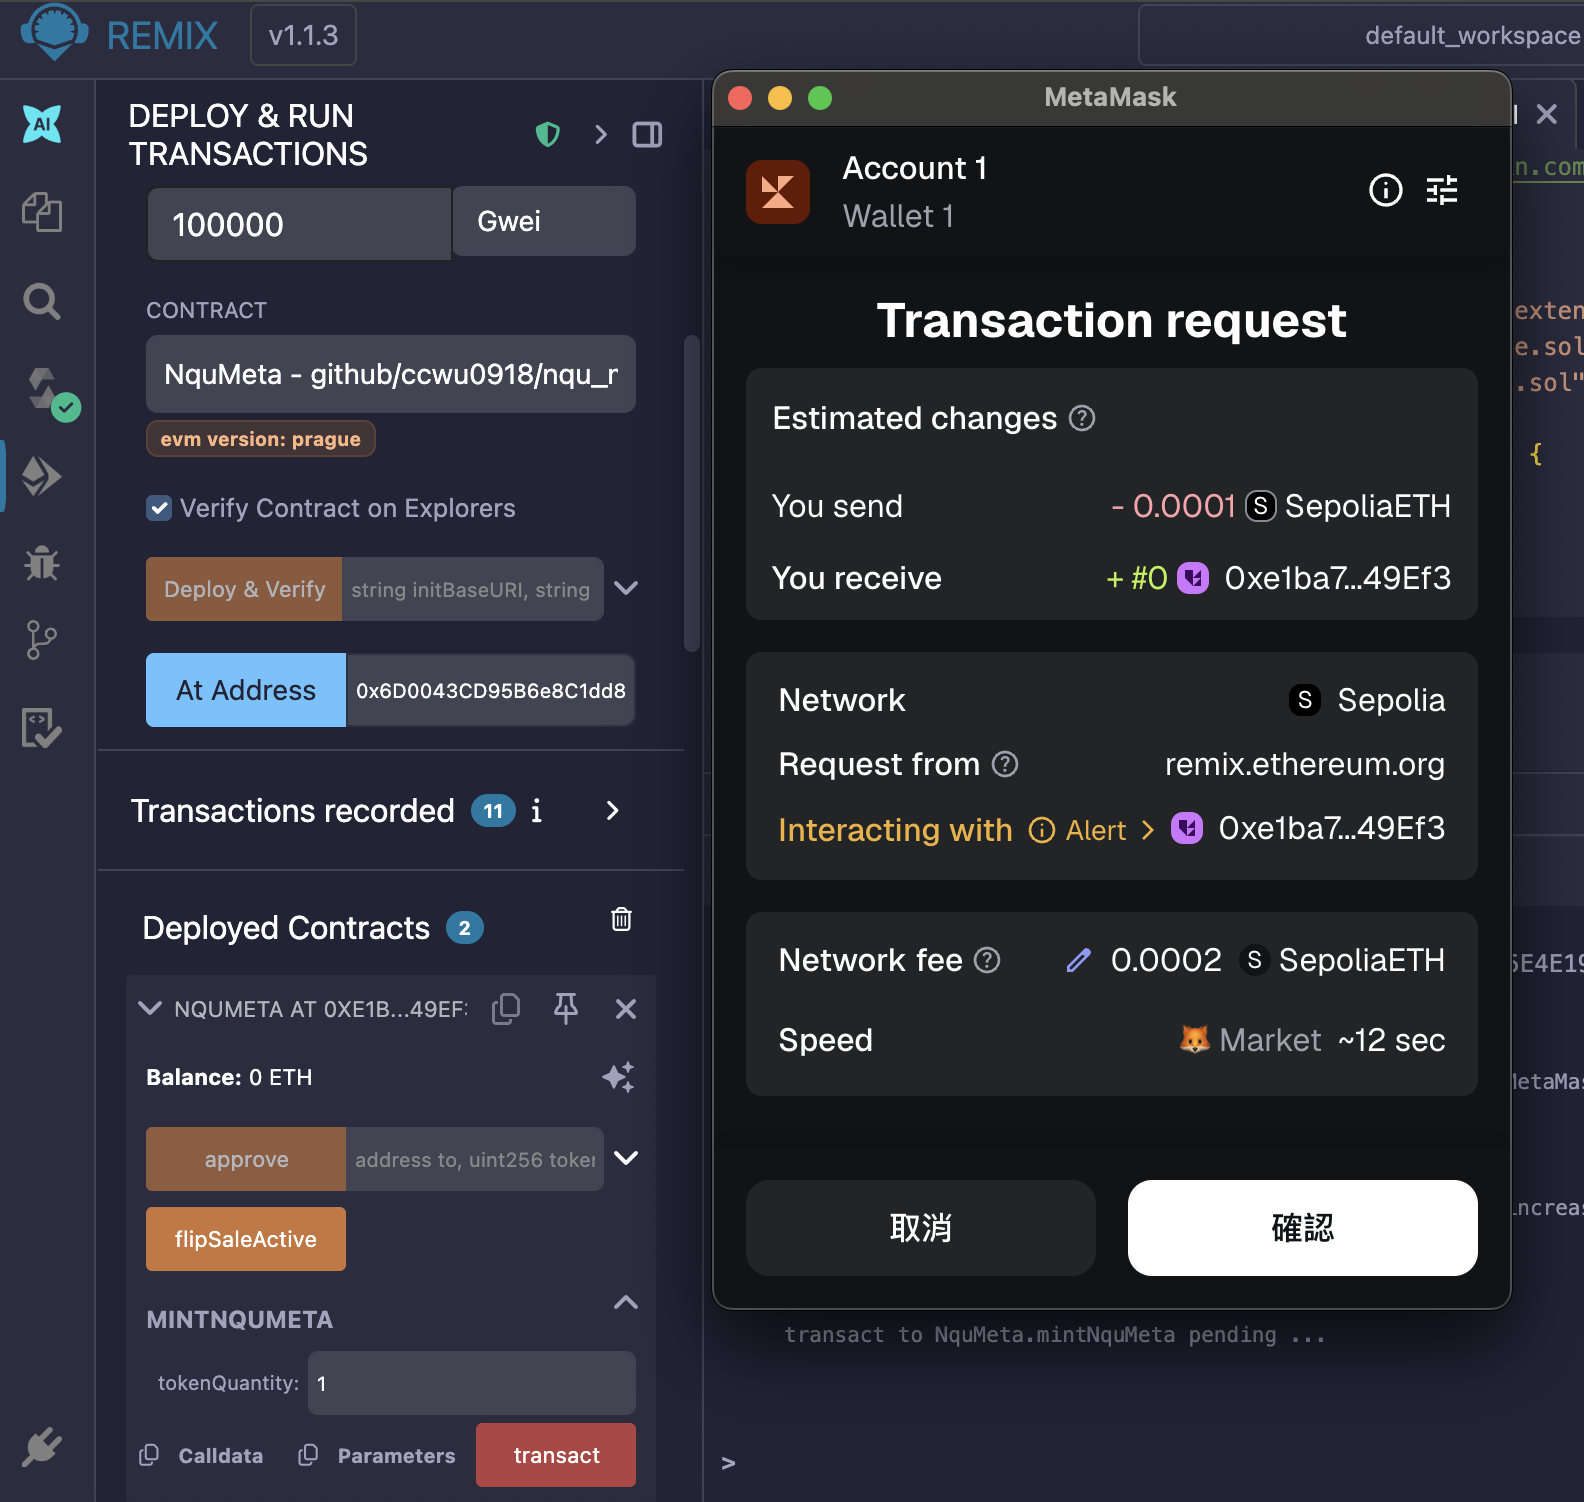

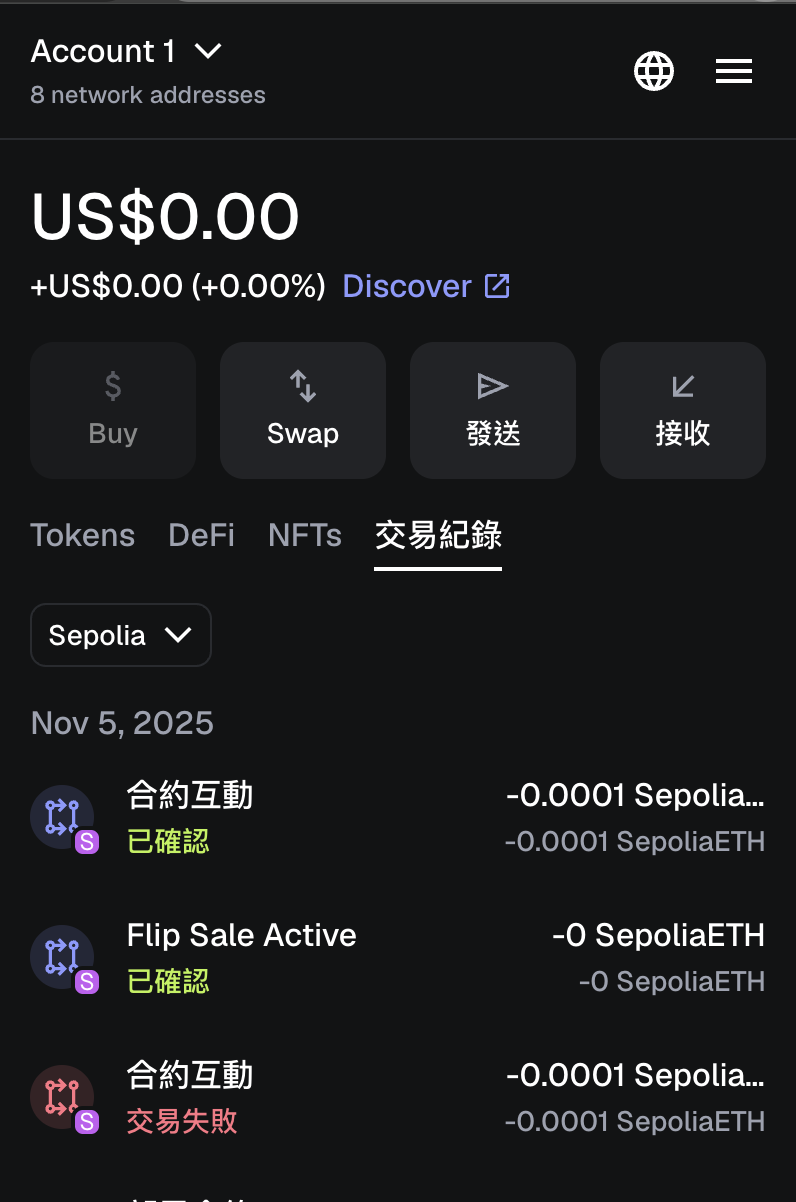

https://sepolia.etherscan.io/nft/0xe1ba77d4d501b9d3795154d59afd90a6eb949ef3/1

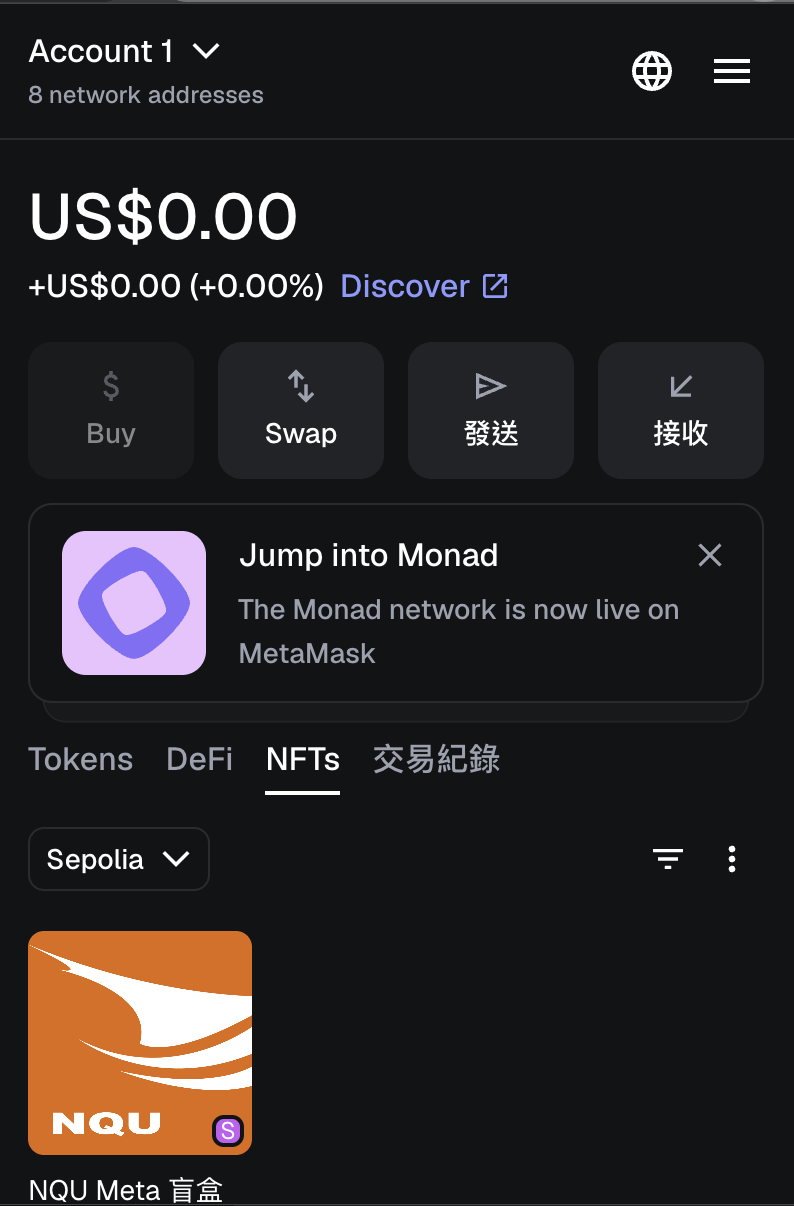

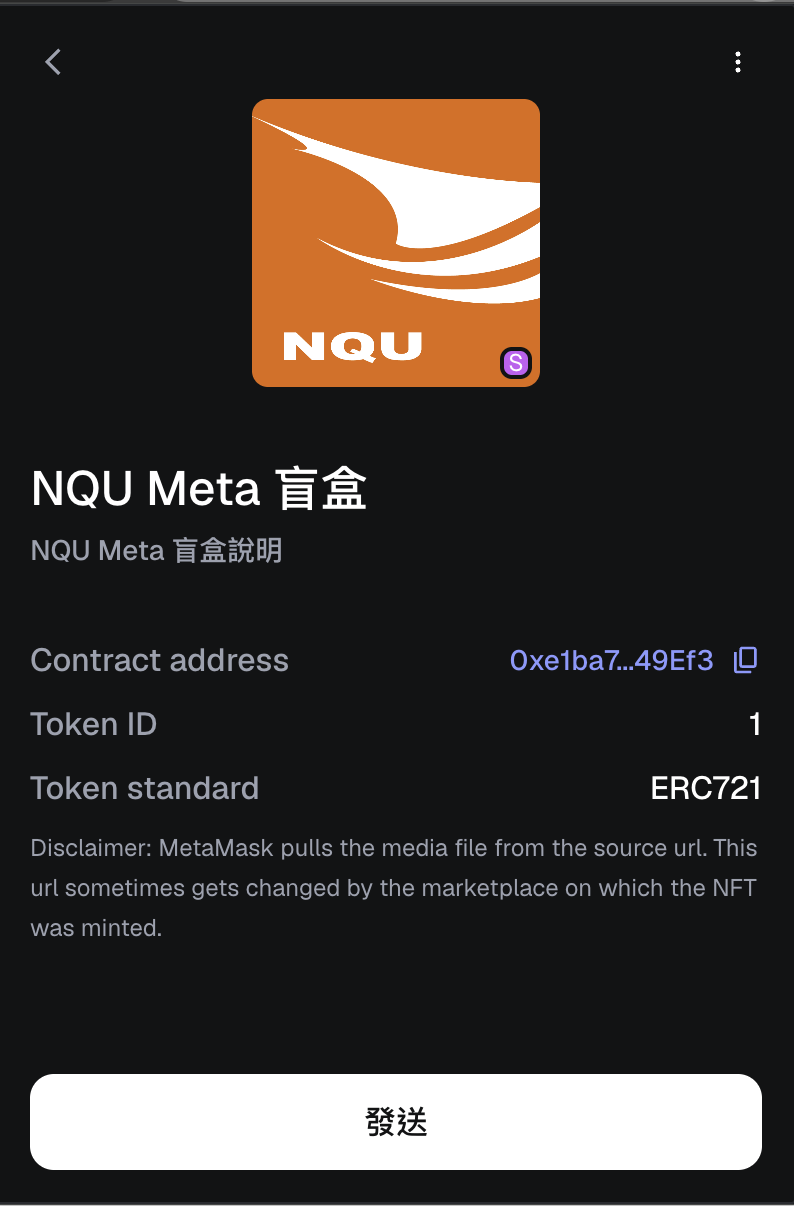

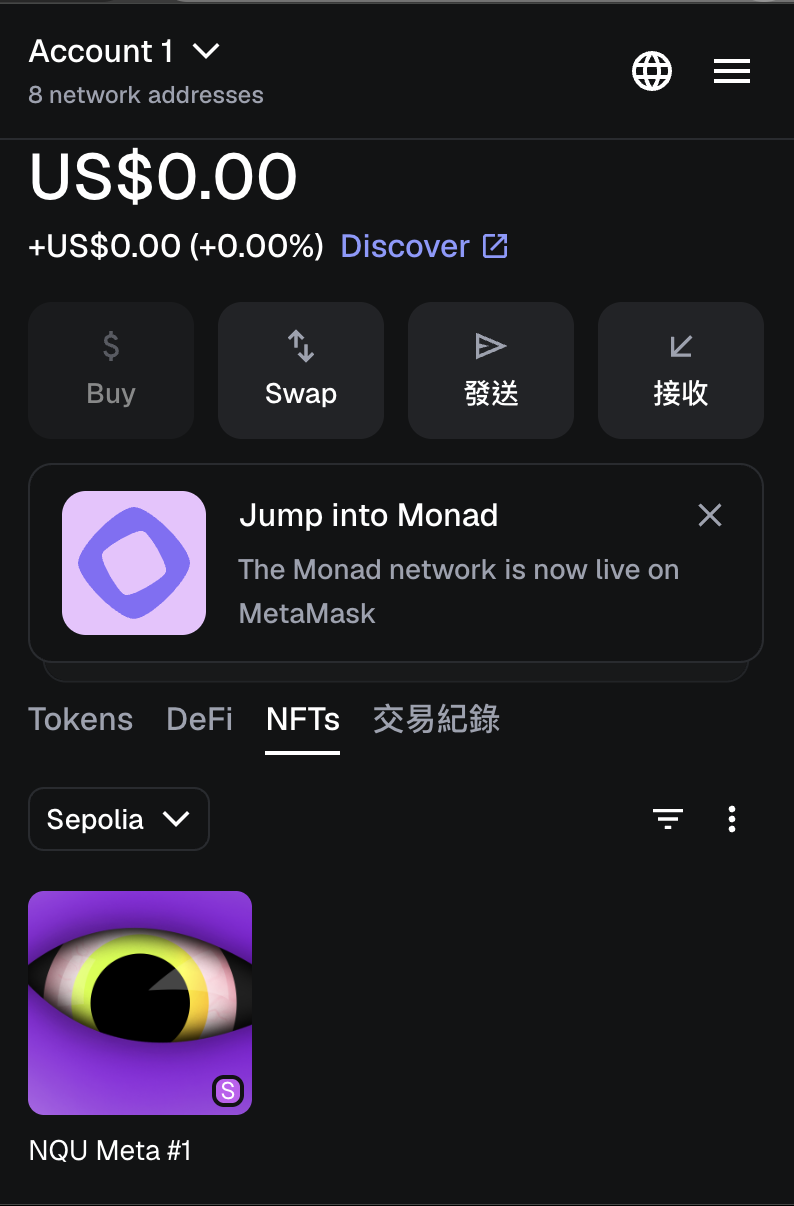

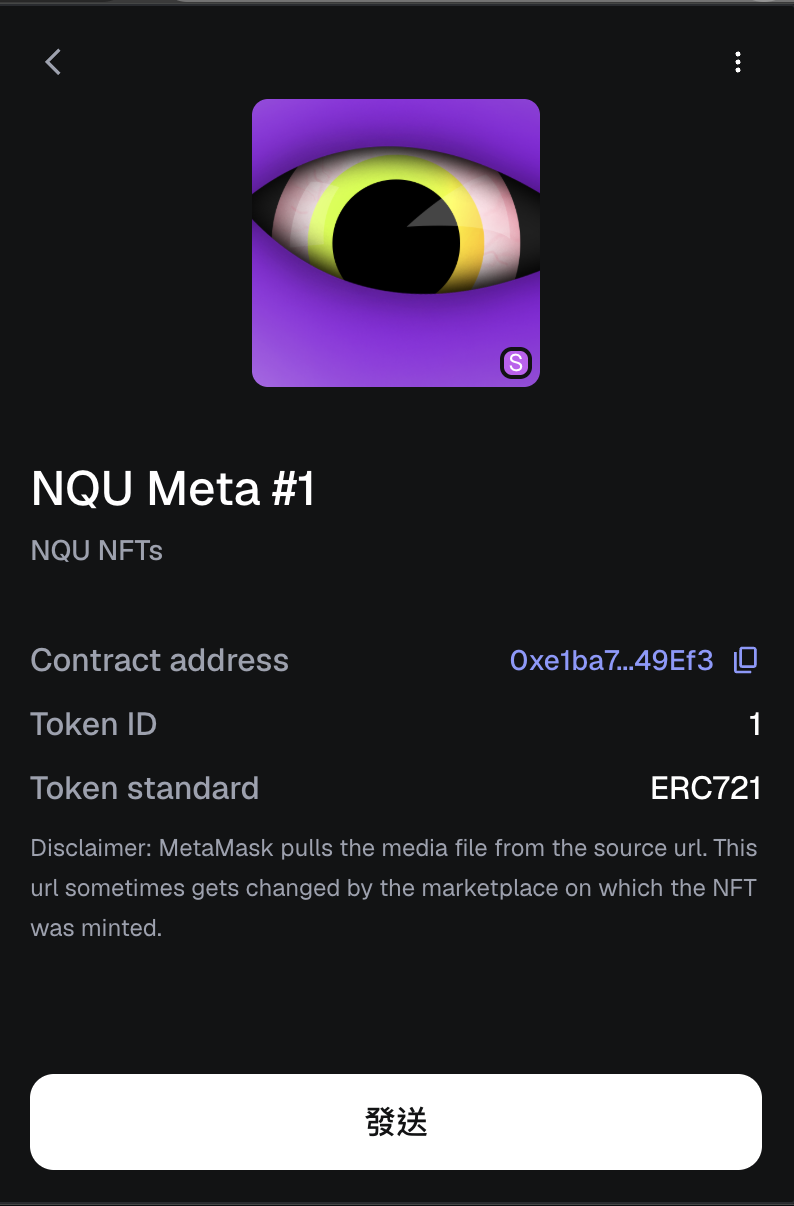

• OpenSea 測試網路- https://testnets.opensea.io

• ThirdWeb 網路- https://thirdweb.com/

• OpenSea 網路- https://opensea.io/

• SolSea 網路- https://solsea.io/login/

• HashLips 組圖專案- https://github.com/HashLips/hashlips_art_engine



1.   _notRevealedURI: https://ipfs.io/ipfs/bafkreignhq3b6srrvenn4kkbsuvg5jpidt24rs5446f3nohx3u236cmeu4
2.   _newBaseURI:
https://ipfs.io/ipfs/bafybeibxuin3ros2dxkax5l4cfcsyfuuqqc6qsjo5e47yct7tkske5wqtu/

In [ ]:
%%writefile /content/NQU_Unpack.json
{
  "name": "NQU Meta 盲盒",
  "description": "NQU Meta 盲盒說明",
  "image": "https://ipfs.io/ipfs/QmfZopS6hKcpfzNyntrBwDuoQQwpMnzW3QqTt8eTBTEXMc"
}

In [ ]:
from google.colab import files
files.download("/content/NQU_Unpack.json")

In [ ]:
!git clone https://github.com/HashLips/hashlips_art_engine

In [ ]:
!apt-get update
!apt-get install -y libcairo2-dev libpango1.0-dev libjpeg-dev libgif-dev librsvg2-dev

In [ ]:
cd hashlips_art_engine

In [ ]:
!sed -i 's/let i = network == NETWORK.sol ? 0 : 1/let i = 0/' ./src/main.js

In [ ]:
!npm install canvas --build-from-source

In [ ]:
!npm audit fix

In [ ]:
!npm install

In [ ]:
!npm run

In [ ]:
!npm run build

In [ ]:
!npm run preview

In [ ]:
%%writefile ./src/config.js
const basePath = process.cwd();
const { MODE } = require(`${basePath}/constants/blend_mode.js`);
const { NETWORK } = require(`${basePath}/constants/network.js`);

const network = NETWORK.eth;

// General metadata for Ethereum
const namePrefix = "NQU Meta"; // "Your Collection"
const description = "NQU NFTs" // "Remember to replace this description"
const baseUri = "https://ipfs.io/ipfs/bafybeib2u2mk2cmexig4i2ip6khx3ht4ez7wmiwlstxiblfljrlhx7gwoe"; // "ipfs://NewUriToReplace"


const solanaMetadata = {
  symbol: "NQUCoin",
  seller_fee_basis_points: 1000, // Define how much % you want from secondary market sales 1000 = 10%
  external_url: "https://www.youtube.com/c/ccwu0918",
  creators: [
    {
      address: "DNRVj69fPqvqLifcszt5XP54D92fsih4cDTSqAr6vB38",
      share: 100,
    },
  ],
};

// If you have selected Solana then the collection starts from 0 automatically
const layerConfigurations = [
  {
    growEditionSizeTo: 10,
    layersOrder: [
      { name: "Background" },
      { name: "Eyeball" },
      { name: "Eye color" },
      { name: "Iris" },
      { name: "Shine" },
      { name: "Bottom lid" },
      { name: "Top lid" },
    ],
  },
];

const shuffleLayerConfigurations = false;

const debugLogs = false;

const format = {
  width: 512,
  height: 512,
  smoothing: false,
};

const gif = {
  export: false,
  repeat: 0,
  quality: 100,
  delay: 500,
};

const text = {
  only: false,
  color: "#ffffff",
  size: 20,
  xGap: 40,
  yGap: 40,
  align: "left",
  baseline: "top",
  weight: "regular",
  family: "Courier",
  spacer: " => ",
};

const pixelFormat = {
  ratio: 2 / 128,
};

const background = {
  generate: true,
  brightness: "80%",
  static: false,
  default: "#000000",
};

const extraMetadata = {};

const rarityDelimiter = "#";

const uniqueDnaTorrance = 10000;

const preview = {
  thumbPerRow: 5,
  thumbWidth: 50,
  imageRatio: format.height / format.width,
  imageName: "preview.png",
};

const preview_gif = {
  numberOfImages: 5,
  order: "ASC", // ASC, DESC, MIXED
  repeat: 0,
  quality: 100,
  delay: 500,
  imageName: "preview.gif",
};

module.exports = {
  format,
  baseUri,
  description,
  background,
  uniqueDnaTorrance,
  layerConfigurations,
  rarityDelimiter,
  preview,
  shuffleLayerConfigurations,
  debugLogs,
  extraMetadata,
  pixelFormat,
  text,
  namePrefix,
  network,
  solanaMetadata,
  gif,
  preview_gif,
};

In [ ]:
!npm run build

In [ ]:
!npm run preview

In [ ]:
!npm run update_info

In [ ]:
!zip -r /content/META_IMAGES.zip ./build/images

In [ ]:
from google.colab import files
files.download("/content/META_IMAGES.zip")

In [ ]:
!zip -r /content/META_JSONS.zip ./build/json

In [ ]:
from google.colab import files
files.download("/content/META_JSONS.zip")



---



# Connect to Ethereum node with Web3 Python

https://youtu.be/DsAoff7yudQ?si=JPMl_cnSdNbaifgy

In [ ]:
# !pip install pyngrok
# from pyngrok import ngrok
# public_url = ngrok.connect(8545, "http")
# print(public_url)

In [ ]:
# !pip install web3
!pip install web3[tester]

In [ ]:
from web3 import Web3

In [ ]:
Web3

# Tools for testing Ethereum applications



https://pypi.org/project/eth-tester/

In [ ]:
# !pip install eth-tester[py-evm]

# Task
How to send a transaction using EthereumTester

Send a transaction using EthereumTester.

In [ ]:
from eth_tester import EthereumTester
t = EthereumTester()

## Get accounts

### Subtask:
Retrieve the available accounts from the `EthereumTester` instance.


**Reasoning**:
Retrieve the available accounts from the EthereumTester instance and store them in a variable, then print the variable.



In [ ]:
t.get_accounts()

In [ ]:
accounts = t.get_accounts()
print(accounts)

In [ ]:
from eth_account import Account

In [ ]:
import eth_tester.backends.pyevm
print(dir(eth_tester.backends.pyevm))

In [ ]:
from web3 import Web3
# from web3.providers.eth_tester import EthereumTesterProvider
# from web3 import EthereumTesterProvider

# 連接到 Ethereum Tester
# w3 = Web3(EthereumTesterProvider())
w3 = Web3(Web3.EthereumTesterProvider())

# 檢查是否連接成功
# assert w3.is_connected()

In [ ]:
# 檢查是否連接成功
w3.is_connected()

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block

## Prepare transaction

### Subtask:
Create a transaction dictionary with details like the sender, recipient, value, and gas.


In [ ]:
# w3.auto_mine_transactions = True

**Reasoning**:
Create a transaction dictionary with the specified details using the accounts retrieved earlier and print it.



In [ ]:
nonce = w3.eth.get_transaction_count(accounts[0])
# nonce = t.get_nonce(accounts[0])

In [ ]:
nonce

In [ ]:
# Check the balance of the sender account (accounts[0])
sender_balance = w3.eth.get_balance(accounts[0])
print(f"Sender balance: {w3.from_wei(sender_balance, 'ether')} Ether")

# Check the balance of the receiver account (accounts[1])
receiver_balance = w3.eth.get_balance(accounts[1])
print(f"Receiver balance: {w3.from_wei(receiver_balance, 'ether')} Ether")

In [ ]:
transaction = {
    'from': accounts[0],
    'to': accounts[1],
    'value': w3.to_wei(10, 'ether'),
    'gas': 21000,
    'gasPrice': w3.to_wei(1, 'gwei'),
    'nonce': w3.eth.get_transaction_count(accounts[0]),
    'chainId': w3.eth.chain_id
}

transaction

In [ ]:
# The EthereumTesterProvider handles signing internally when using w3.eth.send_transaction
# Send the transaction using one of the pre-funded accounts from EthereumTester
tx_hash = w3.eth.send_transaction(transaction)
tx_hash

In [ ]:
tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
tx_receipt

In [ ]:
# Check the balance of the sender account (accounts[0])
sender_balance = w3.eth.get_balance(accounts[0])
print(f"Sender balance: {w3.from_wei(sender_balance, 'ether')} Ether")

# Check the balance of the receiver account (accounts[1])
receiver_balance = w3.eth.get_balance(accounts[1])
print(f"Receiver balance: {w3.from_wei(receiver_balance, 'ether')} Ether")

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block

In [ ]:
# Create a wallet/account
account = w3.eth.account.create()
private_key = account.key
print("Address:", account.address)
print("Private Key:", account.key.hex())

In [ ]:
# Check the balance of the sender account (accounts[0])
sender_balance = w3.eth.get_balance(accounts[0])
print(f"Sender balance: {w3.from_wei(sender_balance, 'ether')} Ether")

# Check the balance of the receiver account (accounts[1])
receiver_balance = w3.eth.get_balance(account.address)
print(f"Receiver balance: {w3.from_wei(receiver_balance, 'ether')} Ether")

In [ ]:
transaction = {
    'from': accounts[0],
    'to': account.address,
    'value': w3.to_wei(100, 'ether'),
    'gas': 21000,
    'gasPrice': w3.to_wei(1, 'gwei'),
    'nonce': w3.eth.get_transaction_count(accounts[0]),
    'chainId': w3.eth.chain_id
}

transaction

In [ ]:
# The EthereumTesterProvider handles signing internally when using w3.eth.send_transaction
# Send the transaction using one of the pre-funded accounts from EthereumTester
tx_hash = w3.eth.send_transaction(transaction)
tx_hash

In [ ]:
tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
tx_receipt

In [ ]:
# Check the balance of the sender account (accounts[0])
sender_balance = w3.eth.get_balance(accounts[0])
print(f"Sender balance: {w3.from_wei(sender_balance, 'ether')} Ether")

# Check the balance of the receiver account (accounts[1])
receiver_balance = w3.eth.get_balance(account.address)
print(f"Receiver balance: {w3.from_wei(receiver_balance, 'ether')} Ether")

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block

## Sign transaction

### Subtask:
Sign the transaction using the private key of the sender account.


**Reasoning**:
Sign the transaction using the private key of the sender account.



In [ ]:
w3.eth.account.from_key(account.key).address

In [ ]:
private_key = account.key

In [ ]:
private_key

In [ ]:
# Send a transaction (example, testnet recommended)
txn = {
    'to': accounts[1], # '0xRecipientAddress'
    'value': w3.to_wei(5, 'ether'),
    'gas': 21000,
    'gasPrice': w3.to_wei('50', 'gwei'),
    'nonce': w3.eth.get_transaction_count(account.address),
    'chainId': w3.eth.chain_id
}
txn

In [ ]:
# Sign the transaction using the private key of the sender account.

# w3.eth.accounts.index_to_key[0]
signed_txn = w3.eth.account.sign_transaction(txn, private_key)

signed_txn

w3.eth.send_raw_transaction(signed_txn.raw_transaction)

In [ ]:
# Check the balance of the sender account (accounts[0])
sender_balance = w3.eth.get_balance(account.address)
print(f"Sender balance: {w3.from_wei(sender_balance, 'ether')} Ether")

# Check the balance of the receiver account (accounts[1])
receiver_balance = w3.eth.get_balance(accounts[1])
print(f"Receiver balance: {w3.from_wei(receiver_balance, 'ether')} Ether")

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block



---



# Task
Deploy a simple smart contract using Web3.py and EthereumTester.

In [ ]:
!pip install py-solc-x

In [ ]:
# @title
# check if notebook is in colab
try:
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "solc-select"])
    !solc-select install 0.8.20
    !solc-select use 0.8.20
    !solc --version

# rely on local installation if the notebook is not in colab
except:
    pass

In [ ]:
from solcx import install_solc

install_solc('0.8.30')

## Write the smart contract

### Subtask:
Write the Solidity code for a simple smart contract.


**Reasoning**:
Write the Solidity code for a simple smart contract and store it in a variable.



In [ ]:
contract_source_code = """
pragma solidity ^0.8.0;

contract SimpleStorage {
    uint256 public storedData;

    function set(uint256 x) public {
        storedData = x;
    }

    function get() public view returns (uint256) {
        return storedData;
    }
}
"""

In [ ]:
contract_source_code = """
// SPDX-License-Identifier: GPL-3.0

pragma solidity >=0.8.2 <0.9.0;

/**
 * @title Storage
 * @dev Store & retrieve value in a variable
 * @custom:dev-run-script ./scripts/deploy_with_ethers.ts
 */
contract Storage {

    uint256 number;

    /**
     * @dev Store value in variable
     * @param num value to store
     */
    function store(uint256 num) public {
        number = num;
    }

    /**
     * @dev Return value
     * @return value of 'number'
     */
    function retrieve() public view returns (uint256){
        return number;
    }
}
"""

## Compile the smart contract

### Subtask:
Compile the Solidity code using `solcx` to get the bytecode and ABI.


**Reasoning**:
Import the necessary function from solcx and compile the Solidity code to get the abi and bytecode.



**Reasoning**:
Correct the syntax error in the previous code block and re-compile the Solidity code to get the abi and bytecode.



**Reasoning**:
The solcx module is not found, so install it using pip.



**Reasoning**:
Since installing 'solcx' directly failed, try installing 'py-solc-x' which provides the necessary functionality.



**Reasoning**:
Import the compile_source function from solcx and compile the Solidity code to get the abi and bytecode as the py-solc-x package has been installed.



**Reasoning**:
Solc is not installed, so install the recommended version (0.8.20) using `solcx.install_solc()`.



**Reasoning**:
Now that solc is installed, compile the Solidity code using `compile_source` to get the abi and bytecode.



**Reasoning**:
Correct the typo in `output_attriutes` to `output_values` and re-compile the Solidity code to get the abi and bytecode.



Build a Hello World Solidity smart contract in Colab

In [ ]:
# from solcx import SolidityCompiler

In [ ]:
from solcx import compile_source

compiled_sol = compile_source(
    contract_source_code,
    output_values=['abi', 'bin'],
    solc_version='0.8.30'
)

abi = compiled_sol['<stdin>:Storage']['abi']
bytecode = compiled_sol['<stdin>:Storage']['bin']

In [ ]:
abi

In [ ]:
bytecode

## Deploy the smart contract

### Subtask:
Use Web3.py to deploy the compiled smart contract to the Ethereum tester.


**Reasoning**:
Get the deployer account, create the contract factory, build the deployment transaction, send the transaction, wait for the receipt, extract the contract address, and print it.



In [ ]:
deployer_account = accounts[0]

SimpleStorage = w3.eth.contract(abi=abi, bytecode=bytecode)

transaction = SimpleStorage.constructor().build_transaction({
    'from': deployer_account,
    'gas': 1000000, # Increased gas limit for deployment
    'gasPrice': w3.to_wei(1, 'gwei'),
    'nonce': w3.eth.get_transaction_count(deployer_account),
})

tx_hash = w3.eth.send_transaction(transaction)

tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)

contract_address = tx_receipt.contractAddress

contract_address

## Verify deployment

### Subtask:
Confirm the smart contract has been deployed successfully.


**Reasoning**:
Create a contract instance using the deployed contract address and ABI, then call the get() function and print the result.



In [ ]:
contract_instance = w3.eth.contract(address=contract_address, abi=abi)

initial_value = contract_instance.functions.retrieve().call()
print(f"Initial value of storedData: {initial_value}")

In [ ]:
contract_instance = w3.eth.contract(address=contract_address, abi=abi)

contract_instance.functions.store(200).transact({'from': accounts[0]})

new_value = contract_instance.functions.retrieve().call()

print(f"Initial value of storedData: {new_value}")

In [ ]:
wallet0 = w3.to_checksum_address(accounts[0])

In [ ]:
print(w3.eth.get_balance(wallet0))

In [ ]:
print(w3.from_wei(w3.eth.get_balance(wallet0), 'ether'))

In [ ]:
wallet1 = w3.to_checksum_address(accounts[1])

In [ ]:
print(w3.eth.get_balance(wallet1))

In [ ]:
print(w3.from_wei(w3.eth.get_balance(wallet1), 'ether'))

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block

In [ ]:
print(w3.is_address('0x1234567890123456789012345678901234567890'))

In [ ]:
print(w3.is_address('0xf5E128551d45F7baeaDb6c7f0DAa17Cb9678Ba41'))

In [ ]:
wallet = w3.to_checksum_address('0xf5E128551d45F7baeaDb6c7f0DAa17Cb9678Ba41')

In [ ]:
print(w3.eth.get_balance(wallet))

In [ ]:
print(w3.from_wei(111111111111111111111, 'ether'))

In [ ]:
print(w3.from_wei(w3.eth.get_balance(wallet), 'ether'))



---



# Connect to Ethereum mainnet with HTTP provider Infura

https://www.infura.io/zh

https://developer.metamask.io/

In [ ]:
# Connect to an Ethereum node (e.g., Ganache, Infura, Alchemy, etc.)

# provider_url = 'http://127.0.0.1:8545'
# provider_url = "https://mainnet.infura.io/v3/YOUR_INFURA_KEY"
provider_url = 'https://mainnet.infura.io/v3/01279796ef4f413c97c75f5e6adf4fdb'

w3 = Web3(Web3.HTTPProvider(provider_url))
w3.is_connected()

In [ ]:
from eth_account import Account
# Load your private key (replace with your actual private key)
# It's crucial to handle private keys securely and never hardcode them in production.
# private_key = b'YOUR_PRIVATE_KEY_IN_BYTES'
# account = Account.from_key(private_key)

# Build an unsigned transaction
# nonce = w3.eth.get_transaction_count(account.address)

# Interact with bloakchain contract with Web3 Python

https://etherscan.io/

https://etherscan.io/address/0xe592427a0aece92de3edee1f18e0157c05861564#code

In [ ]:
abi = '[{"inputs":[{"internalType":"address","name":"_factory","type":"address"},{"internalType":"address","name":"_WETH9","type":"address"}],"stateMutability":"nonpayable","type":"constructor"},{"inputs":[],"name":"WETH9","outputs":[{"internalType":"address","name":"","type":"address"}],"stateMutability":"view","type":"function"},{"inputs":[{"components":[{"internalType":"bytes","name":"path","type":"bytes"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint256","name":"amountIn","type":"uint256"},{"internalType":"uint256","name":"amountOutMinimum","type":"uint256"}],"internalType":"struct ISwapRouter.ExactInputParams","name":"params","type":"tuple"}],"name":"exactInput","outputs":[{"internalType":"uint256","name":"amountOut","type":"uint256"}],"stateMutability":"payable","type":"function"},{"inputs":[{"components":[{"internalType":"address","name":"tokenIn","type":"address"},{"internalType":"address","name":"tokenOut","type":"address"},{"internalType":"uint24","name":"fee","type":"uint24"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint256","name":"amountIn","type":"uint256"},{"internalType":"uint256","name":"amountOutMinimum","type":"uint256"},{"internalType":"uint160","name":"sqrtPriceLimitX96","type":"uint160"}],"internalType":"struct ISwapRouter.ExactInputSingleParams","name":"params","type":"tuple"}],"name":"exactInputSingle","outputs":[{"internalType":"uint256","name":"amountOut","type":"uint256"}],"stateMutability":"payable","type":"function"},{"inputs":[{"components":[{"internalType":"bytes","name":"path","type":"bytes"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint256","name":"amountOut","type":"uint256"},{"internalType":"uint256","name":"amountInMaximum","type":"uint256"}],"internalType":"struct ISwapRouter.ExactOutputParams","name":"params","type":"tuple"}],"name":"exactOutput","outputs":[{"internalType":"uint256","name":"amountIn","type":"uint256"}],"stateMutability":"payable","type":"function"},{"inputs":[{"components":[{"internalType":"address","name":"tokenIn","type":"address"},{"internalType":"address","name":"tokenOut","type":"address"},{"internalType":"uint24","name":"fee","type":"uint24"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint256","name":"amountOut","type":"uint256"},{"internalType":"uint256","name":"amountInMaximum","type":"uint256"},{"internalType":"uint160","name":"sqrtPriceLimitX96","type":"uint160"}],"internalType":"struct ISwapRouter.ExactOutputSingleParams","name":"params","type":"tuple"}],"name":"exactOutputSingle","outputs":[{"internalType":"uint256","name":"amountIn","type":"uint256"}],"stateMutability":"payable","type":"function"},{"inputs":[],"name":"factory","outputs":[{"internalType":"address","name":"","type":"address"}],"stateMutability":"view","type":"function"},{"inputs":[{"internalType":"bytes[]","name":"data","type":"bytes[]"}],"name":"multicall","outputs":[{"internalType":"bytes[]","name":"results","type":"bytes[]"}],"stateMutability":"payable","type":"function"},{"inputs":[],"name":"refundETH","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"value","type":"uint256"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint8","name":"v","type":"uint8"},{"internalType":"bytes32","name":"r","type":"bytes32"},{"internalType":"bytes32","name":"s","type":"bytes32"}],"name":"selfPermit","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"nonce","type":"uint256"},{"internalType":"uint256","name":"expiry","type":"uint256"},{"internalType":"uint8","name":"v","type":"uint8"},{"internalType":"bytes32","name":"r","type":"bytes32"},{"internalType":"bytes32","name":"s","type":"bytes32"}],"name":"selfPermitAllowed","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"nonce","type":"uint256"},{"internalType":"uint256","name":"expiry","type":"uint256"},{"internalType":"uint8","name":"v","type":"uint8"},{"internalType":"bytes32","name":"r","type":"bytes32"},{"internalType":"bytes32","name":"s","type":"bytes32"}],"name":"selfPermitAllowedIfNecessary","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"value","type":"uint256"},{"internalType":"uint256","name":"deadline","type":"uint256"},{"internalType":"uint8","name":"v","type":"uint8"},{"internalType":"bytes32","name":"r","type":"bytes32"},{"internalType":"bytes32","name":"s","type":"bytes32"}],"name":"selfPermitIfNecessary","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"amountMinimum","type":"uint256"},{"internalType":"address","name":"recipient","type":"address"}],"name":"sweepToken","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"address","name":"token","type":"address"},{"internalType":"uint256","name":"amountMinimum","type":"uint256"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"feeBips","type":"uint256"},{"internalType":"address","name":"feeRecipient","type":"address"}],"name":"sweepTokenWithFee","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"int256","name":"amount0Delta","type":"int256"},{"internalType":"int256","name":"amount1Delta","type":"int256"},{"internalType":"bytes","name":"_data","type":"bytes"}],"name":"uniswapV3SwapCallback","outputs":[],"stateMutability":"nonpayable","type":"function"},{"inputs":[{"internalType":"uint256","name":"amountMinimum","type":"uint256"},{"internalType":"address","name":"recipient","type":"address"}],"name":"unwrapWETH9","outputs":[],"stateMutability":"payable","type":"function"},{"inputs":[{"internalType":"uint256","name":"amountMinimum","type":"uint256"},{"internalType":"address","name":"recipient","type":"address"},{"internalType":"uint256","name":"feeBips","type":"uint256"},{"internalType":"address","name":"feeRecipient","type":"address"}],"name":"unwrapWETH9WithFee","outputs":[],"stateMutability":"payable","type":"function"},{"stateMutability":"payable","type":"receive"}]'

In [ ]:
# contract_address = '0xE592427A0AEce92De3Edee1F18E0157C05861564'

In [ ]:
contract_address = Web3.to_checksum_address('0xE592427A0AEce92De3Edee1F18E0157C05861564')

In [ ]:
contract_instance = w3.eth.contract(address=contract_address, abi=abi)

In [ ]:
contract_instance.functions.factory().call()

In [ ]:
contract_instance.functions.WETH9().call()

# Interact with Ethereum blockchain with Web3 Python

In [ ]:
latest_block_number = w3.eth.block_number

latest_block_number

In [ ]:
latest_block = w3.eth.get_block(latest_block_number)

latest_block

In [ ]:
print(w3.is_address('0x1234567890123456789012345678901234567890'))

In [ ]:
print(w3.is_address('0xf5E128551d45F7baeaDb6c7f0DAa17Cb9678Ba41'))

In [ ]:
wallet = w3.to_checksum_address('0xf5E128551d45F7baeaDb6c7f0DAa17Cb9678Ba41')

In [ ]:
print(w3.eth.get_balance(wallet))

In [ ]:
print(w3.from_wei(111111111111111111111, 'ether'))

In [ ]:
print(w3.from_wei(w3.eth.get_balance(wallet), 'ether'))

## Summary:

### Data Analysis Key Findings

*   The task successfully deployed a simple `SimpleStorage` smart contract to an Ethereum tester environment using Web3.py.
*   The initial value of the `storedData` variable in the deployed contract was confirmed to be 0.
*   The `get()` function of the deployed contract was successfully called to retrieve the initial value.

### Insights or Next Steps

*   The process demonstrates the basic steps required to compile, deploy, and interact with a simple smart contract on an Ethereum-compatible network using Python and Web3.py.
*   The next step could involve calling the `set()` function on the deployed contract to change the value of `storedData` and then verifying the change using the `get()` function.
